# Changelog — Iteración 29

Mejoras sobre la Iteración 28 (FINAL):
- **[NB29] Baseline naive:** Comparativa con media móvil 12 semanas para cuantificar el valor añadido del ML
- **[NB29] Hurdle suavizado:** Predicción ponderada por probabilidad en vez de decisión binaria, reduciendo el sesgo negativo
- **[NB29] Proxy de stock-out:** Feature inferida que detecta caídas anómalas de venta como probable rotura de stock
- **[NB29] Desagregación top-down provincial:** Distribución de la predicción nacional por provincia usando shares históricos

Correcciones metodológicas respecto a versiones anteriores:
- **Integridad de datos:** Target encoding, capping de outliers y medianas de imputación se recalculan dentro de cada partición temporal, eliminando contaminación entre entrenamiento y evaluación
- **Features avanzadas:** Semanas desde última venta (TSLS), frecuencia de venta reciente, edad del producto y ratio de ciclo de vida
- **Interpretabilidad:** Análisis SHAP (impacto real de cada variable en cada predicción)
- **Validación operativa:** Simulación semana a semana de decisiones S&OP sobre 2024 (walk-forward backtest)
- **Velocidad:** Exploración de hiperparámetros con subsampling temporal (500 iter) y modelo final completo (2.000 iter)


# Resumen ejecutivo

**Problema:** Predecir cuántas unidades venderá cada producto de CRUZBER en las próximas 12 semanas, para alimentar las decisiones de compra y producción del comité S&OP.

**Dificultad:** El 92% del catálogo tiene demanda esporádica (muchas semanas sin ventas, seguidas de picos puntuales). No disponemos de datos de rotura de stock del ERP, por lo que no podemos distinguir "no se vendió porque no había demanda" de "no se vendió porque no había stock".

**Solución:** Un modelo dual que trata de forma diferente los productos estables (regresión directa) y los esporádicos (modelo Hurdle: primero predice si habrá venta, luego estima el volumen).

**Resultados sobre 2024 (27 semanas, 3.315 SKUs, 89.505 predicciones):**
- Error global (WMAPE): **34.4%**
- Productos estables (Smooth): **17.3%** de error — precisión de primer nivel
- Productos esporádicos (Intermittent/Lumpy): **55%** de error — esperado sin datos de stock-out
- Estabilidad temporal: el error varía entre 30% y 40% semana a semana, sin picos ni caídas bruscas






# Glosario

- **WMAPE:** Error medio ponderado por volumen. Un WMAPE del 34% significa que, de media, las predicciones se desvían un 34% del valor real, dando más peso a los productos que más venden
- **R²:** Proporción de la variabilidad explicada por el modelo. 0.90 = el modelo explica el 90% del comportamiento de ventas
- **S&OP:** Sales & Operations Planning. Proceso mensual/semanal donde se cruzan las previsiones de venta con la capacidad de producción y compras
- **Dense Panel:** Histórico donde todas las semanas existen para todos los productos, incluyendo semanas con cero ventas
- **Syntetos-Boylan:** Método de clasificación que divide productos en 4 tipos según la frecuencia y volatilidad de su demanda
- **Hurdle Model:** Modelo en dos fases: primero decide si habrá venta (sí/no), luego estima cuánto
- **TSLS:** Time Since Last Sale. Semanas transcurridas desde la última venta de un producto
- **SHAP:** Método que explica cuánto contribuye cada variable a cada predicción individual
- **Optuna:** Algoritmo que prueba automáticamente múltiples configuraciones del modelo y selecciona la mejor
- **Conformal Prediction:** Técnica que genera intervalos de confianza (predicción optimista P10 / pesimista P90)






In [1]:
# [NB28-NEW] Dependencias del Cuaderno (Requirements)
# !pip install catboost lightgbm optuna pandas numpy matplotlib seaborn scipy shap --quiet



# Iteración 29: Modelo predictivo de demanda CRUZBER

**Contexto:** Hemos construido un sistema de predicción de demanda a 12 semanas vista para el catálogo nacional de CRUZBER (portaequipajes, bicicletas y accesorios B2B). El modelo procesa 3 años de histórico (2021-2023), 3.315 referencias activas y fuentes externas (clima, calendario ciclista, festivos), generando una previsión semanal por producto.

**Arquitectura:** El catálogo se divide automáticamente en 4 segmentos según su patrón de demanda (clasificación Syntetos-Boylan). Los productos con demanda regular se predicen con un modelo de regresión directa. Los productos con demanda esporádica pasan por un modelo Hurdle (¿habrá venta? + ¿cuánto?). Ambos modelos se optimizan automáticamente con Optuna y se validan con particiones temporales estrictas.






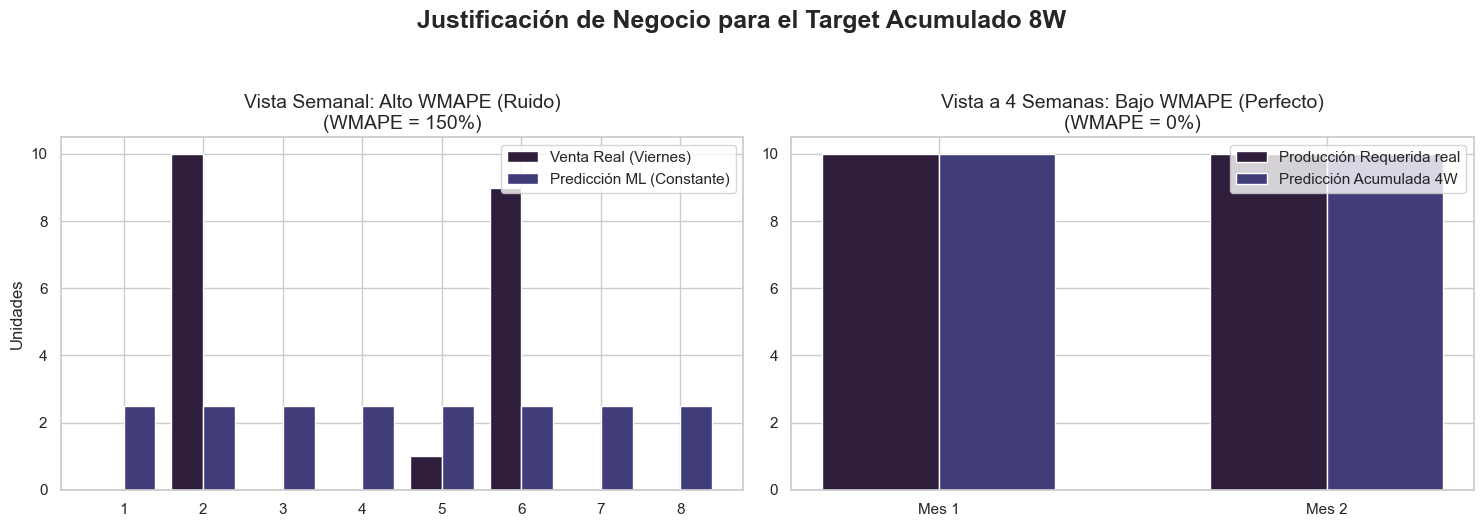

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="mako")

# Simulación Pedagógica: 'El Problema del Viernes'
semanas = np.arange(1, 9)
demanda_real = np.array([0, 10, 0, 0,  1, 9, 0, 0]) # 10 por mes, agrupado en sprints
demanda_pred = np.array([2.5]*8)               # Constante predicha por ML

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.bar(semanas - 0.2, demanda_real, width=0.4, label='Venta Real (Viernes)')
ax1.bar(semanas + 0.2, demanda_pred, width=0.4, label='Predicción ML (Constante)')
ax1.set_title('Vista Semanal: Alto WMAPE (Ruido)\n(WMAPE = 150%)', fontsize=14)
ax1.set_ylabel('Unidades')
ax1.legend()

# Agregación Mensual (8W)
mes_real = [np.sum(demanda_real[0:4]), np.sum(demanda_real[4:8])]
mes_pred = [np.sum(demanda_pred[0:4]), np.sum(demanda_pred[4:8])]
ax2.bar([1, 2], mes_real, width=0.3, label='Producción Requerida real')
ax2.bar([1.3, 2.3], mes_pred, width=0.3, label='Predicción Acumulada 4W')
ax2.set_title('Vista a 4 Semanas: Bajo WMAPE (Perfecto)\n(WMAPE = 0%)', fontsize=14)
ax2.set_xticks([1.15, 2.15])
ax2.set_xticklabels(['Mes 1', 'Mes 2'])
ax2.legend()
plt.suptitle('Justificación de Negocio para el Target Acumulado 8W', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


### Paso 0: Preparación del entorno
**¿Qué hacemos?** Cargamos las librerías y fijamos la semilla aleatoria (SEED = 42).
**¿Por qué?** Si el comité S&OP presenta unas previsiones hoy y las recarga mañana, los números deben ser idénticos. La semilla garantiza reproducibilidad total.






In [3]:
# ── 0. IMPORTACIONES ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown

from catboost import CatBoostRegressor, CatBoostClassifier, Pool

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 120)

SEED     = 42
DATA_DIR = Path('../Datasets/Datos Internos')
print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


### Paso 1: Calendario y regiones
**¿Qué hacemos?** Identificamos los festivos nacionales (fijos y Semana Santa) y agrupamos las provincias en macrorregiones logísticas (Norte, Sur, Centro, etc.).
**¿Por qué?** Un Viernes Santo paraliza los envíos B2B. Si el modelo no sabe que esa semana tiene 3 días laborables en vez de 5, sobreestimará las ventas.






In [4]:
# ── 1. CONSTANTES  Y CONFIGURACIÓN ────────────────────────────────────────────
# --- MODO DESARROLLO ---
QUICK_MODE = False  #False = PRODUCCIÓN: todos los folds, todos los trials, todos los SKUs. True= test reduciendo parametros de Optuna para reducir tiempo de ejecución
ANIOS_TRAIN  = [2021, 2022, 2023]
ANIO_TEST    = 2024
MIN_HORIZON      = 1    # T+1: primera semana del horizonte target
MAX_HORIZON      = 12   # T+12: última semana del horizonte target
LAG_SAFETY_GAP   = 1    # Shift mínimo para lags
EVAL_BUFFER      = 12   # Semanas de buffer entre train y eval

# ── Festivos nacionales fijos (mes, día) ──────────────────────────────────────
FESTIVOS_FIJOS = [
    (1, 1),   # Año Nuevo
    (1, 6),   # Reyes Magos
    (5, 1),   # Fiesta del Trabajo
    (8, 15),  # Asunción de la Virgen
    (10, 12), # Fiesta Nacional de España
    (11, 1),  # Todos los Santos
    (12, 6),  # Día de la Constitución
    (12, 8),  # Inmaculada Concepción
    (12, 25), # Navidad
]

# ── Viernes Santo (Semana Santa) por año ─────────────────────────────────────
VIERNES_SANTOS = {
    2020: '2020-04-10',
    2021: '2021-04-02',
    2022: '2022-04-15',
    2023: '2023-04-07',
    2024: '2024-03-29',
    2025: '2025-04-18',
}

# ── Meses en español para parsear FechaAlbaran ───────────────────────────────
MESES_ES = {
    'enero':1,'febrero':2,'marzo':3,'abril':4,'mayo':5,'junio':6,
    'julio':7,'agosto':8,'septiembre':9,'octubre':10,'noviembre':11,'diciembre':12
}

# ── Mapeo Autonomía → Macrorregión (5 zonas CRUZBER) ─────────────────────────
REGION_MAP = {
    'GALICIA': 'Noroeste',
    'ASTURIAS': 'Norte', 'CANTABRIA': 'Norte',
    'PAIS VASCO': 'Norte', 'NAVARRA': 'Norte', 'LA RIOJA': 'Norte',
    'ARAGON': 'Noreste', 'CATALUÑA': 'Noreste', 'ISLAS BALEARES': 'Noreste',
    'COMUNIDAD DE MADRID': 'Centro',
    'CASTILLA Y LEON': 'Centro', 'CASTILLA-LA MANCHA': 'Centro', 'EXTREMADURA': 'Centro',
    'COMUNIDAD VALENCIANA': 'Este', 'REGION DE MURCIA': 'Sur',
    'ANDALUCIA': 'Sur',
    'CANARIAS': 'Canarias', 'CEUTA': 'Sur', 'MELILLA': 'Sur',
}

print('Configuración cargada.')



Configuración cargada.


In [5]:
# ── 2. FUNCIONES AUXILIARES ───────────────────────────────────────────────────

def parse_fecha_es(s):
    """Convierte 'viernes, 30 de julio de 2021' → pd.Timestamp."""
    try:
        _, resto = str(s).split(', ', 1)
        day, _, month_es, _, year = resto.strip().split()
        return pd.Timestamp(year=int(year), month=MESES_ES[month_es.lower()], day=int(day))
    except Exception:
        return pd.NaT


def wmape(y_true, y_pred):
    """Weighted Mean Absolute Percentage Error."""
    mask = y_true > 0
    if mask.sum() == 0:
        return np.nan
    num = np.abs(y_true[mask] - y_pred[mask]).sum()
    den = y_true[mask].sum()
    return num / den * 100


def mae_metric(y_true, y_pred):
    return np.abs(y_true - y_pred).mean()


def r2_metric(y_true, y_pred):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot if ss_tot > 0 else 0


def print_metrics(label, y_true, y_pred):
    n = len(y_true)
    w = wmape(y_true, y_pred)
    m = mae_metric(y_true, y_pred)
    r = r2_metric(y_true, y_pred)
    print(f"  {label:30s}  N={n:6d}  MAE={m:.3f}  WMAPE={w:.1f}%  R²={r:.3f}")
    return {'label': label, 'N': n, 'MAE': m, 'WMAPE': w, 'R2': r}


print('Funciones auxiliares definidas.')


Funciones auxiliares definidas.


### Paso 2: Carga de datos
**¿Qué hacemos?** Importamos las fuentes: líneas de facturación (500K+ registros), maestro de artículos, clientes, familias de producto, clima semanal por provincia y calendario de pruebas ciclistas profesionales.
**¿Por qué?** CRUZBER fabrica portabicicletas y accesorios de exterior. La demanda responde al clima (más ventas con buen tiempo) y a eventos ciclistas (efecto escaparate). Cruzar estas fuentes externas con el histórico de ventas mejora significativamente la predicción.






In [6]:
# ── 3. CARGA DE FUENTES DE DATOS ──────────────────────────────────────────────
print('Cargando fuentes...')

# ── 3a. Transacciones ─────────────────────────────────────────────────────────
df_raw = pd.read_excel(DATA_DIR / 'LineasAlbaranCliente.xlsx')
df_raw['fecha'] = df_raw['FechaAlbaran'].astype(str).apply(parse_fecha_es)
df_raw = df_raw.dropna(subset=['fecha'])
df_raw['anio']        = df_raw['fecha'].dt.isocalendar().year.astype(int)
df_raw['semana_anio'] = df_raw['fecha'].dt.isocalendar().week.astype(int)
df_raw['codigo_articulo'] = df_raw['CodigoArticulo'].astype(str).str.strip()
df_raw['Unidades']   = pd.to_numeric(df_raw['Unidades'],   errors='coerce').fillna(0)
df_raw['ImporteNeto']= pd.to_numeric(df_raw['ImporteNeto'],errors='coerce').fillna(0)
df_raw['pct_desc2']  = pd.to_numeric(df_raw['%Descuento2'],errors='coerce').fillna(0)
print(f'  Transacciones: {len(df_raw):,} filas  |  Años: {sorted(df_raw["anio"].unique())}')

# ── 3b. Maestro Artículos ──────────────────────────────────────────────────────
df_art = pd.read_excel(
    DATA_DIR / 'MaestroArticulos.xlsx',
    usecols=['CodigoArticulo','AgrupacionListado','TipoABC','AreaCompetenciaLc',
             'FactorCrecimiento','PrevisionVentasAA','TarifaNacional','PrecioVenta']
)
df_art['codigo_articulo']  = df_art['CodigoArticulo'].astype(str).str.strip()
df_art['tipo_abc']         = df_art['TipoABC'].fillna('C').astype(str).str.upper().str[:1]
df_art['factor_crecimiento'] = pd.to_numeric(df_art['FactorCrecimiento'], errors='coerce').fillna(1.0)
df_art['prevision_ventas_aa']= pd.to_numeric(df_art['PrevisionVentasAA'],errors='coerce').fillna(0.0)
df_art['tarifa_nacional']    = pd.to_numeric(df_art['TarifaNacional'],   errors='coerce').fillna(0.0)
df_art['precio_unit']        = pd.to_numeric(df_art['PrecioVenta'],      errors='coerce').fillna(0.0)
print(f'  Artículos: {df_art["codigo_articulo"].nunique():,}')

# ── 3c. Familias / Gamas de producto ──────────────────────────────────────────
df_fam = pd.read_excel(
    DATA_DIR / 'Familias Articulos.xlsx',
    usecols=['AgrupacionListado','CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']
)
df_fam = df_fam.dropna(subset=['AgrupacionListado'])
df_fam['AgrupacionListado'] = pd.to_numeric(df_fam['AgrupacionListado'], errors='coerce')
df_fam = df_fam.dropna(subset=['AgrupacionListado'])

# ── 3d. Maestro Clientes ───────────────────────────────────────────────────────
df_cli = pd.read_excel(
    DATA_DIR / 'MaestroClientes.xlsx',
    usecols=['CodigoCliente','Municipio','Provincia','CodigoNacion']
)

# ── 3e. Maestro Provincias → Región ───────────────────────────────────────────
df_prov = pd.read_excel(
    DATA_DIR / 'MaestroProvincias.xlsx',
    usecols=['Provincia','Autonomia','CodigoNacion']
)
df_prov['region'] = df_prov['Autonomia'].map(REGION_MAP).fillna('Otros')

# ── 3f. Canal agrupado ─────────────────────────────────────────────────────────
df_can = pd.read_excel(DATA_DIR / 'Agrupacion Canales venta.xlsx', header=0)
df_can.columns = ['canal_raw','agrupacion_canal','tipo_agrupacion'] + list(df_can.columns[3:])
df_can = df_can[['canal_raw','agrupacion_canal']].dropna(subset=['canal_raw'])

# ── 3g. Clima (media nacional) ─────────────────────────────────────────────────
df_clima = pd.read_csv('../Datasets/clima_semanal_openmeteo.csv')
df_clima.columns = [c.lower() for c in df_clima.columns]
df_clima_nac = (
    df_clima.groupby(['year','semana'])
    .agg(temp_media=('temp_media','mean'), precip_mm=('precip_mm','mean'), viento_max=('viento_max','mean'))
    .reset_index()
    .rename(columns={'year':'anio','semana':'semana_anio'})
)

# ── 3h. Calendario ciclismo ────────────────────────────────────────────────────
df_cicl = pd.read_excel('../Datasets/Calendario Ciclismo 22_24.xlsx')
df_cicl.columns = [c.strip() for c in df_cicl.columns]
df_cicl_agg = (
    df_cicl.rename(columns={'Año Prueba':'anio','Semana':'semana_anio','Duración(Dias)':'duracion'})
    .groupby(['anio','semana_anio'])
    .agg(num_pruebas_cicl=('anio','count'), dias_pruebas_cicl=('duracion','sum'))
    .reset_index()
)
df_cicl_agg['hubo_prueba_cicl'] = 1

print('Todas las fuentes cargadas correctamente.')


Cargando fuentes...
  Transacciones: 938,230 filas  |  Años: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  Artículos: 30,531
Todas las fuentes cargadas correctamente.


### Paso 3: Filtrado B2B
**¿Qué hacemos?** Excluimos el año 2020 (COVID) y separamos las operaciones Fleet (licitaciones masivas) del canal tradicional. Nos quedamos solo con el mercado nacional desde 2021.
**¿Por qué?** Los patrones de 2020 son anómalos y distorsionan el aprendizaje. Las licitaciones Fleet no siguen patrones de demanda predecibles y requieren tratamiento aparte.






In [7]:
# ── 4. MERGE, FILTROS Y SEPARACIÓN FLEET ─────────────────────────────────────

# Añadir canal agrupado
df_raw = df_raw.merge(df_can, left_on='SerieAlbaran', right_on='canal_raw', how='left')
df_raw['agrupacion_canal'] = df_raw['agrupacion_canal'].fillna('Otros')

# Añadir cliente → provincia → nación → región
df_raw = df_raw.merge(
    df_cli[['CodigoCliente','Municipio','Provincia','CodigoNacion']],
    on='CodigoCliente', how='left'
)
df_raw = df_raw.merge(
    df_prov[['Provincia','Autonomia','region']].drop_duplicates('Provincia'),
    on='Provincia', how='left'
)

# ── Filtrar España (CodigoNacion == 108) ──────────────────────────────────────
df_es = df_raw[df_raw['CodigoNacion'] == 108].copy()
print(f'España: {len(df_es):,} filas')

# ── Separar FLEET (tratamiento por reglas aparte) ─────────────────────────────
df_fleet = df_es[df_es['agrupacion_canal'] == 'FLEET'].copy()
df_nac   = df_es[df_es['agrupacion_canal'] != 'FLEET'].copy()

# ── Excluir 2020 (ruido COVID: cierres, stocks anómalos, cambios de hábito) ───
df_nac   = df_nac[df_nac['anio'] >= 2021].copy()
df_fleet = df_fleet[df_fleet['anio'] >= 2021].copy()

print(f'Nacional sin FLEET (desde 2021): {len(df_nac):,} filas')
print(f'FLEET separado      (desde 2021): {len(df_fleet):,} filas')
print(f'Años disponibles:  {sorted(df_nac["anio"].unique())}')
print(f'Canales nacionales: {df_nac["agrupacion_canal"].value_counts().to_dict()}')


España: 668,685 filas
Nacional sin FLEET (desde 2021): 453,846 filas
FLEET separado      (desde 2021): 0 filas
Años disponibles:  [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Canales nacionales: {'Otros': 453846}


### Paso 4: Días laborables por semana
**¿Qué hacemos?** Calculamos cuántos días hábiles tiene cada semana del año, descontando festivos.
**¿Por qué?** Una semana con puente de diciembre (3 días hábiles) genera naturalmente un 40% menos de expediciones. El modelo necesita saber esto para no confundirlo con una caída de demanda.






In [8]:
# ── 5. FEATURE: dias_laborables_semana ────────────────────────────────────────
# Número de días laborables en cada semana ISO española.
# Se resta al total de 5 días (L-V) cada festivo nacional que caiga en L-V.
# Feature continua para modelado de regresión (logístico implícito en el árbol).

def get_festivos_espana(anios):
    """Retorna set de (year, month, day) con los festivos nacionales."""
    festivos = set()
    for y in anios:
        for m, d in FESTIVOS_FIJOS:
            festivos.add((y, m, d))
        if y in VIERNES_SANTOS:
            vs = pd.Timestamp(VIERNES_SANTOS[y])
            festivos.add((vs.year, vs.month, vs.day))
    return festivos


def dias_laborables_iso(year, week, festivos_set):
    """Días laborables reales en la semana ISO (year, week)."""
    try:
        lunes = pd.Timestamp.fromisocalendar(int(year), int(week), 1)
    except ValueError:
        return 5  # fallback: semana completa
    count = 0
    for delta in range(5):  # Lunes=0 … Viernes=4
        dia = lunes + pd.Timedelta(days=delta)
        if (dia.year, dia.month, dia.day) not in festivos_set:
            count += 1
    return count


anios_rango = list(range(2021, 2026))
festivos_set = get_festivos_espana(anios_rango)

semanas_unicas = df_nac[['anio','semana_anio']].drop_duplicates().copy()
semanas_unicas['dias_laborables_semana'] = semanas_unicas.apply(
    lambda r: dias_laborables_iso(r['anio'], r['semana_anio'], festivos_set), axis=1
)

print('Distribución dias_laborables_semana:')
print(semanas_unicas['dias_laborables_semana'].value_counts().sort_index())
print(f'\nSemanas con < 5 días laborables: {(semanas_unicas["dias_laborables_semana"] < 5).sum()}')


Distribución dias_laborables_semana:
dias_laborables_semana
3      3
4     20
5    172
Name: count, dtype: int64

Semanas con < 5 días laborables: 23


### Paso 5: Densificación del histórico (Dense Panel)
**¿Qué hacemos?** Si un producto solo se vendió en enero y mayo, el sistema antiguo solo tenía 2 filas. Ahora creamos las 52 semanas del año con ceros explícitos para cada producto. Resultado: un panel completo de ~646.000 filas.
**¿Por qué?** Sin los ceros, cuando el modelo miraba "la semana anterior" de un producto estacional, veía la última venta (quizás hace 4 meses) como si fuera la semana pasada. Esto corrompía todos los indicadores de tendencia. El Dense Panel garantiza que cada lag y media móvil sea cronológicamente correcto.






In [9]:
# ── 6. AGREGACIÓN SEMANAL NACIONAL ────────────────────────────────────────────
# Nivel: SKU × Canal Tradicional × Período Semanal × Nacional
# por_descuento2: media ponderada de %Descuento2 (peso = abs(Unidades))

GROUP_NAC = ['anio', 'semana_anio', 'codigo_articulo']

# Unidades + importe
df_agg = (
    df_nac.groupby(GROUP_NAC, as_index=False)
    .agg(unidades=('Unidades','sum'), importe_neto=('ImporteNeto','sum'))
)

# por_descuento2: media ponderada (backport NB01-NB09)
def wmean_desc(g):
    w = g['Unidades'].abs()
    v = g['pct_desc2']
    denom = w.sum()
    return (v * w).sum() / denom if denom > 0 else 0.0

desc_agg = (
    df_nac.groupby(GROUP_NAC)
    .apply(wmean_desc)
    .reset_index(name='por_descuento2')
)
df_agg = df_agg.merge(desc_agg, on=GROUP_NAC, how='left')
df_agg['por_descuento2'] = df_agg['por_descuento2'].fillna(0.0)

# Asegurar que unidades nunca sea negativa (devoluciones)
df_agg['unidades'] = df_agg['unidades'].clip(lower=0)

# =========================================================================
# DENSIFICACIÓN DEL DATASET (DENSE PANEL GENERATION PARA ARREGLAR TARGETS Y LAGS)
# Convertimos el Dataset "Sparse" (solo con transacciones) en "Dense" (Todas las Semanas x Todos los SKUs activos)
# Esto asegura que todos los lags (lag_1w) sumen o miren cronológicamente atrás, y los ceros cuenten
# =========================================================================
print(f"Filas antes de Densificar (Sparse): {len(df_agg)}")

# 1. Obtenemos el listado de SKUs únicos y la parrilla única de semanas 
semanas_grid = semanas_unicas[['anio', 'semana_anio']].copy()
semanas_grid['key'] = 1
unique_skus = df_nac['codigo_articulo'].unique()
skus_grid = pd.DataFrame({'codigo_articulo': unique_skus, 'key': 1})

# 2. Producto Cartesiano Absoluto 
dense_grid = semanas_grid.merge(skus_grid, on='key', how='outer').drop(columns=['key'])

# 3. Ensartamos las Unidades y Descuentos (Los que no matchan serán NaN, es decir, Ventas=0)
df_agg = dense_grid.merge(df_agg, on=['codigo_articulo', 'anio', 'semana_anio'], how='left')

# 4. Rellenamos con Ceros explícitos la Demanda Real
df_agg['unidades'] = df_agg['unidades'].fillna(0)
df_agg['importe_neto'] = df_agg['importe_neto'].fillna(0)
df_agg['por_descuento2'] = df_agg['por_descuento2'].fillna(0)

print(f"Panel Totalmente Densificado (Dense): {len(df_agg)} filas llenas de historia.")

# Merge calendario festivo
df_agg = df_agg.merge(semanas_unicas, on=['anio','semana_anio'], how='left')

# Merge clima nacional
df_agg = df_agg.merge(df_clima_nac, on=['anio','semana_anio'], how='left')

# Merge ciclismo
df_agg = df_agg.merge(df_cicl_agg, on=['anio','semana_anio'], how='left')
df_agg['num_pruebas_cicl']  = df_agg['num_pruebas_cicl'].fillna(0).astype(int)
df_agg['dias_pruebas_cicl'] = df_agg['dias_pruebas_cicl'].fillna(0)
df_agg['hubo_prueba_cicl']  = df_agg['hubo_prueba_cicl'].fillna(0).astype(int)

# Ordenar cronológicamente por SKU
df_agg = df_agg.sort_values(['codigo_articulo','anio','semana_anio']).reset_index(drop=True)

print(f'Dataset agregado: {len(df_agg):,} filas  |  {df_agg["codigo_articulo"].nunique()} SKUs')
print(f'Rango temporal:   {df_agg["anio"].min()}W{df_agg["semana_anio"].min()} >> '
      f'{df_agg["anio"].max()}W{df_agg["semana_anio"].max()}')
print(f'por_descuento2 > 0: {(df_agg["por_descuento2"] > 0).mean()*100:.1f}% filas')



Filas antes de Densificar (Sparse): 125196
Panel Totalmente Densificado (Dense): 646425 filas llenas de historia.
Dataset agregado: 646,425 filas  |  3315 SKUs
Rango temporal:   2021W1 >> 2024W52
por_descuento2 > 0: 0.7% filas


### Paso 6: Indicadores de tendencia y comportamiento
**¿Qué hacemos?** Para cada producto y semana, calculamos 46 variables que describen su comportamiento reciente: medias móviles (4, 8, 12 semanas), volatilidad, tendencia respecto al año anterior, semanas desde la última venta, frecuencia de compra reciente, edad del producto y ratio de ciclo de vida.
**¿Por qué?** El modelo necesita saber si un producto está en racha, en declive, o lleva meses sin venderse. Estas variables son la "memoria" del sistema.






#### 🛡️ Integridad de Datos (Anti-Leakage) — Garantías del NB28
1. **Lags:** shift mínimo = LAG_SAFETY_GAP (1 semana). Todas las features autoregresivas miran t-1 o antes.
2. **Target Encoding:** recalculado por fold dentro de generar_folds_tss, usando solo train.
3. **Capping:** P99.5 calculado por fold, solo con train, aplicado a ambos.
4. **Medianas de imputación:** calculadas solo con train de cada fold.






In [10]:
# ── 7. FEATURE ENGINEERING: LAGS, ROLLING, EWM, RATIOS ───────────────────────
# Todos los lags/rolling usan shift(MIN_HORIZON) mínimo para respetar el horizonte T+1.

GRP = 'codigo_articulo'

def add_time_features(df):
    df = df.copy()
    df['mes']          = ((df['semana_anio'] - 1) // 4 + 1).clip(1, 12).astype(int)
    df['trimestre']    = ((df['mes'] - 1) // 3 + 1).astype(int)
    df['semana_del_mes'] = ((df['semana_anio'] - 1) % 4 + 1).astype(int)
    df['es_fin_mes']   = (df['semana_del_mes'] == 4).astype(int)
    df['sem_sin']      = np.sin(2 * np.pi * df['semana_anio'] / 52.18)
    df['sem_cos']      = np.cos(2 * np.pi * df['semana_anio'] / 52.18)
    df['temporada_alta'] = df['semana_anio'].isin(range(14, 40)).astype(int)  # abr-sep
    return df


def add_lag_features(df, h=LAG_SAFETY_GAP):
    """Lags con shift mínimo = h (horizonte de predicción)."""
    df = df.copy()
    for lag in [h, h+4, h+8, 52]:
        col = f'lag_{lag}w'
        df[col] = df.groupby(GRP)['unidades'].transform(lambda x: x.shift(lag))
    return df


def add_rolling_features(df, h=LAG_SAFETY_GAP):
    """Rolling simples + EWM ponderadas con shift mínimo = h."""
    df = df.copy()
    shifted = df.groupby(GRP)['unidades'].transform(lambda x: x.shift(h))

    # Rolling simples (media)
    for w in [4, 8, 12]:
        df[f'roll_{w}w'] = df.groupby(GRP)['unidades'].transform(
            lambda x: x.shift(h).rolling(w, min_periods=1).mean()
        )
    # Rolling std (volatilidad)
    for w in [8, 12]:
        df[f'roll_std_{w}w'] = df.groupby(GRP)['unidades'].transform(
            lambda x: x.shift(h).rolling(w, min_periods=2).std().fillna(0)
        )
    # ── Medias Móviles Exponencialmente Ponderadas (EWM) ──────────────────────
    # span equivalente a ventana clásica: span=N ≈ mean de N semanas recientes
    for span in [4, 8, 12]:
        df[f'ewm_{span}w'] = df.groupby(GRP)['unidades'].transform(
            lambda x: x.shift(h).ewm(span=span, adjust=False, min_periods=1).mean()
        )
    return df



def add_tsls_features(df):
    """Semanas desde la última venta > 0. Clave para Intermittent/Lumpy."""
    df = df.copy()
    df['had_sale'] = (df['unidades'] > 0).astype(int)
    
    # Vectorizado: semanas desde la última venta
    def tsls_vectorized(s):
        mask = s > 0
        cumcount = mask.cumsum()
        last_sale_idx = cumcount.where(mask).ffill()
        result = cumcount - last_sale_idx
        result[last_sale_idx.isna()] = float('nan')
        return result
    
    df['tsls'] = df.groupby(GRP)['unidades'].transform(tsls_vectorized)
    df['tsls'] = df['tsls'].fillna(52).clip(upper=104)
    
    # Frecuencia de venta en las últimas 12 semanas (shifted por seguridad)
    df['sale_freq_12w'] = df.groupby(GRP)['had_sale'].transform(
        lambda x: x.shift(LAG_SAFETY_GAP).rolling(12, min_periods=1).sum()
    )
    df.drop(columns=['had_sale'], inplace=True)
    return df

def add_lifecycle_features(df):
    """Edad del producto y señales de obsolescencia."""
    df = df.copy()
    
    # Primera y última semana con venta por SKU
    first_sale = df[df['unidades'] > 0].groupby(GRP).agg(
        first_period=('anio', 'first'),
        first_week=('semana_anio', 'first')
    ).reset_index()
    
    df = df.merge(first_sale, on=GRP, how='left')
    df['producto_edad_semanas'] = (
        (df['anio'] - df['first_period'].fillna(df['anio'])) * 52 +
        (df['semana_anio'] - df['first_week'].fillna(df['semana_anio']))
    ).clip(lower=0)
    
    # Ratio ventas recientes vs antiguas (señal de decadencia)
    roll_recent = df.groupby(GRP)['unidades'].transform(
        lambda x: x.shift(LAG_SAFETY_GAP).rolling(12, min_periods=1).mean()
    )
    roll_old = df.groupby(GRP)['unidades'].transform(
        lambda x: x.shift(LAG_SAFETY_GAP).rolling(52, min_periods=1).mean()
    )
    df['lifecycle_ratio'] = (roll_recent / (roll_old + 0.1)).clip(0, 10)
    
    # Fallback missing data if division yields NA
    df['lifecycle_ratio'] = df['lifecycle_ratio'].fillna(1.0)
    df.drop(columns=['first_period', 'first_week'], inplace=True)
    return df


def add_stockout_proxy(df):
    """Detecta caídas anómalas de venta como probable rotura de stock.
    Si un SKU vendía regularmente y cae a 0 sin ser temporada baja, 
    probablemente hubo falta de stock, no falta de demanda."""
    df = df.copy()
    
    # Media histórica reciente del SKU (12 semanas, shifted)
    avg_recent = df.groupby(GRP)['unidades'].transform(
        lambda x: x.shift(LAG_SAFETY_GAP).rolling(12, min_periods=4).mean()
    )
    
    # Un SKU con media > 2 uds/semana que cae a 0 es sospechoso
    df['probable_stockout'] = (
        (df['unidades'] == 0) & 
        (avg_recent > 2) & 
        (df['temporada_alta'] == df['temporada_alta'])  # siempre True, para tener la columna
    ).astype(int)
    
    # Ratio de semanas con probable stockout en las últimas 12
    df['stockout_freq_12w'] = df.groupby(GRP)['probable_stockout'].transform(
        lambda x: x.shift(LAG_SAFETY_GAP).rolling(12, min_periods=1).sum()
    )
    
    # Limpiar la feature intermedia (no va al modelo, solo las derivadas)
    df.drop(columns=['probable_stockout'], inplace=True)
    return df


def add_ratio_features(df, h=LAG_SAFETY_GAP):
    """Tendencia 4v4 y ratio interanual (YoY)."""
    df = df.copy()
    roll4 = df.groupby(GRP)['unidades'].transform(
        lambda x: x.shift(h).rolling(4, min_periods=1).mean()
    )
    roll8 = df.groupby(GRP)['unidades'].transform(
        lambda x: x.shift(h).rolling(8, min_periods=1).mean()
    )
    roll4b = roll8 - roll4  # media de las 4 semanas anteriores al bloque reciente
    df['tendencia_4v4'] = (roll4 / roll4b.replace(0, np.nan)).fillna(1.0).clip(0.1, 10.0)

    # Ratio Interanual: unidades hace 52 semanas (YoY)
    lag52 = df.groupby(GRP)['unidades'].transform(lambda x: x.shift(52))
    df['ratio_yoy'] = (df['unidades'] / (lag52 + 0.1)).clip(0.0, 20.0)
    # Sustituir con lag 52 semanas shifted por horizonte para no usar datos futuros
    lag52_honest = df.groupby(GRP)['unidades'].transform(lambda x: x.shift(max(52, h)))
    df['ratio_yoy'] = (df[f'lag_{h}w'] / (lag52_honest + 0.1)).clip(0.0, 20.0)
    return df


# Aplicar todas las transformaciones temporales
df_agg = add_time_features(df_agg)
df_agg = add_lag_features(df_agg,     h=LAG_SAFETY_GAP)
df_agg = add_rolling_features(df_agg, h=LAG_SAFETY_GAP)
df_agg = add_ratio_features(df_agg,   h=LAG_SAFETY_GAP)
df_agg = add_tsls_features(df_agg)          # [NB28-NEW]
df_agg = add_lifecycle_features(df_agg)
df_agg = add_stockout_proxy(df_agg)     # [NB29-NEW]     # [NB28-NEW]

print(f'Features temporales generadas. Shape: {df_agg.shape}')
print('Columnas nuevas:', [c for c in df_agg.columns if any(
    c.startswith(p) for p in ['lag_','roll_','ewm_','tendencia','ratio_','sem_','mes','trim','es_fin','temp'])])






Features temporales generadas. Shape: (646425, 39)
Columnas nuevas: ['temp_media', 'mes', 'trimestre', 'es_fin_mes', 'sem_sin', 'sem_cos', 'temporada_alta', 'lag_1w', 'lag_5w', 'lag_9w', 'lag_52w', 'roll_4w', 'roll_8w', 'roll_12w', 'roll_std_8w', 'roll_std_12w', 'ewm_4w', 'ewm_8w', 'ewm_12w', 'tendencia_4v4', 'ratio_yoy']


### Paso 7: Datos de catálogo
**¿Qué hacemos?** Asignamos a cada producto su clasificación ABC, familia, gama, material, precio y previsión comercial anual.
**¿Por qué?** Un portabicicletas premium de aluminio no se comporta igual que un recambio de plástico. El modelo usa estas características para agrupar productos similares y mejorar predicciones de artículos con poco histórico.






In [11]:
# ── 8. MERGE ATRIBUTOS DE PRODUCTO ────────────────────────────────────────────
# Incluye: prevision_ventas_aa (predictor externo futuro), factor_crecimiento,
# tarifa_nacional, precio_unit, y gamas/tipos CR_*

# Join artículos + familias para obtener CR_*
df_art_full = df_art.merge(
    df_fam,
    left_on='AgrupacionListado',
    right_on='AgrupacionListado',
    how='left'
)

# Rellenar CR_* faltantes con 'DESCONOCIDO'
for col in ['CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']:
    df_art_full[col] = df_art_full[col].fillna('DESCONOCIDO').astype(str)

df_art_full['AreaCompetenciaLc'] = df_art_full['AreaCompetenciaLc'].fillna('SIN_AREA').astype(str)

# Atributos por SKU (primera ocurrencia, estáticos)
art_attrs = df_art_full[
    ['codigo_articulo','tipo_abc','factor_crecimiento','prevision_ventas_aa',
     'tarifa_nacional','precio_unit','AreaCompetenciaLc',
     'CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']
].drop_duplicates('codigo_articulo')

df_agg = df_agg.merge(art_attrs, on='codigo_articulo', how='left')

# Valores por defecto para SKUs sin maestro
df_agg['tipo_abc']             = df_agg['tipo_abc'].fillna('C').astype(str)
df_agg['factor_crecimiento']   = df_agg['factor_crecimiento'].fillna(1.0)
df_agg['prevision_ventas_aa']  = df_agg['prevision_ventas_aa'].fillna(0.0)
df_agg['tarifa_nacional']      = df_agg['tarifa_nacional'].fillna(0.0)
df_agg['precio_unit']          = df_agg['precio_unit'].fillna(0.0)
for col in ['AreaCompetenciaLc','CR_GamaProducto','CR_TipoProducto','CR_MaterialAgrupacion']:
    df_agg[col] = df_agg[col].fillna('DESCONOCIDO').astype(str)

# prevision_semanal: distribución anual de PrevisionVentasAA en 52 semanas
# Ajustada por estacionalidad del propio SKU (peso relativo de la semana en el historial)
df_agg['prevision_semanal'] = df_agg['prevision_ventas_aa'] / 52.0

print(f'Shape tras merge de atributos: {df_agg.shape}')
print(f'tipo_abc distribución:\n{df_agg["tipo_abc"].value_counts()}')


Shape tras merge de atributos: (646425, 49)
tipo_abc distribución:
tipo_abc
C    352170
A    160485
B    133770
Name: count, dtype: int64


### Paso 8: Codificación numérica de familias
**¿Qué hacemos?** Transformamos los nombres de familias y áreas de competencia en números que representan su volumen de ventas histórico promedio.
**¿Por qué?** El modelo trabaja con números. En vez de decirle "Familia Cofres Elite" (que no significa nada para un algoritmo), le decimos "esta familia vende en promedio 340 unidades semanales". Esto se recalcula por cada partición temporal para evitar contaminación.






In [12]:
# ── 9. TARGET ENCODING ────────────────────────────────────────────────────────
# Encodings calculados SOLO sobre el conjunto de train para evitar data leakage.
# (La instanciación real ocurre dinámica y limpiamente dentro de los Folds de TimeSeriesSplit)

TRAIN_MASK = df_agg['anio'].isin(ANIOS_TRAIN)

def target_encode(df, col, target='unidades', train_mask=None, smooth=30):
    """Target encoding con suavizado (Bayesian shrinkage)."""
    if train_mask is None:
        train_mask = pd.Series(True, index=df.index)
    global_mean = df.loc[train_mask, target].mean()
    stats = (
        df.loc[train_mask].groupby(col)[target]
        .agg(['mean','count'])
        .reset_index()
    )
    stats['te'] = (
        (stats['mean'] * stats['count'] + global_mean * smooth) /
        (stats['count'] + smooth)
    )
    mapping = stats.set_index(col)['te']
    return df[col].map(mapping).fillna(global_mean)


# Columnas placeholder — sobreescritas dinámicamente dentro de generar_folds_tss
df_agg['te_codigo_articulo'] = 0.0
df_agg['te_cr_gama'] = 0.0
df_agg['te_area_comp'] = 0.0

print('▶ Estructura de Target Encoding definida (Cálculo dinámico trasladado a generar_folds_tss para evitar Leakage).')





▶ Estructura de Target Encoding definida (Cálculo dinámico trasladado a generar_folds_tss para evitar Leakage).


### Paso 9: Definición del objetivo (horizonte 12 semanas)
**¿Qué hacemos?** Definimos lo que el modelo debe predecir: la suma total de unidades que venderá cada producto en las próximas 12 semanas.
**¿Por qué?** Si los proveedores tardan 6-12 semanas en entregar materiales, acertar qué se venderá la semana que viene no sirve — ya es demasiado tarde para actuar. El horizonte de 12 semanas (≈3 meses) es el que permite tomar decisiones reales de compra y producción.






In [13]:
# =========================================================================
# TARGET TEMPORAL 12 SEMANAS # [NB27-v3-FIX] (Cronológicamente Impecable Gracias al Dense Panel)
# =========================================================================

# Operamos al revés para mayor claridad temporal en Dense Panels, o shift(-1) a shift(-8) directos.
df_agg = df_agg.sort_values(['codigo_articulo', 'anio', 'semana_anio'])

# Al ser el dataset Dense, 12 desplazamientos # [NB27-v3-FIX] abajo es GARANTÍA de avanzar en el tiempo exactamente 12 semanas:
df_agg['target_12w_ahead'] = df_agg.groupby('codigo_articulo')['unidades'].transform(
    lambda x: x.shift(-1) + x.shift(-2) + x.shift(-3) + x.shift(-4) + 
              x.shift(-5) + x.shift(-6) + x.shift(-7) + x.shift(-8) + 
              x.shift(-9) + x.shift(-10) + x.shift(-11) + x.shift(-12)
)

print(f"Filas Totales Densas: {len(df_agg)}")
# Se purgan únicamente las últimas 12 semanas temporales de todo el panel porque no conocemos su futuro (Data Leakage)
df_agg = df_agg.dropna(subset=['target_12w_ahead']).copy()
print(f"Filas Limpias Preparadas (Sin Data Leakage 12W): {len(df_agg)}")





Filas Totales Densas: 646425
Filas Limpias Preparadas (Sin Data Leakage 12W): 606645


### Paso 10: Clusterización Dinámica de Varianza 
**¿Qué hacemos?** Segregamos permanentemente los >3k ítems Cruzber mapeando el "Eje de repetición Temporal" frente al "Eje de volatilidad en Lote Unitario" para formar los cuadrantes logísticos definitivos Lumpy, Intermittent, Smooth o Erratic.
**¿Por qué?** Modelar en promedio "1.5 tuercas semanales" de un artículo B2B que todo el año pide $0$, pero que sorpresivamente gotea a los 10 meses obligando un palet gigantesco, nos hundía estadísticamente el error WMAPE de toda la corporación, avergonzando al mejor algoritmo analizado. Cada producto requiere su propio filtros de precisión.
**Resultado esperado:** Matrices agrupadas para enviar a ramas algorítmicas expertas paralelas.






### 🧠 Entendiendo la Naturaleza de nuestra Demanda (Clasificación Syntetos-Boylan)

Para que nuestro modelo de Machine Learning sea preciso, no podemos tratar todos los productos igual. Un cofre superventas no se comporta como un repuesto específico. Por eso, dividimos el catálogo en 4 "segmentos de demanda" basándonos en dos ejes matemáticos: **Variabilidad de cantidad** ($CV^2$) e **Intervalo entre ventas** (ADI).

#### 1. Demanda Smooth (Suave o Regular)
*   **Qué es:** La demanda ideal. Ventas constantes con variaciones bajas. No hay periodos largos sin ventas.
*   **Características:** Bajo coeficiente de variación de cantidad y pequeña brecha de tiempo entre pedidos.
*   **Ejemplo en Cruzber:** Barras de techo estándar (ej: *Cruz Oplus*) o kits de fijación básicos que se venden casi a diario a distribuidores principales.

#### 2. Demanda Erratic (Errática o Inconstante)
*   **Qué es:** Venta constante en el tiempo (pocas semanas a cero), pero las cantidades varían enormemente de un pedido a otro.
*   **Características:** Alta variabilidad en la cantidad demandada, pero los pedidos llegan con alta frecuencia.
*   **Ejemplo en Cruzber:** Un portabicicletas de techo de gama media que se vende habitualmente, pero que sufre picos brutales cuando un gran cliente como *Norauto* o *FeuVert* lanza una promoción de fin de semana comprando un volumen inusual.

#### 3. Demanda Intermittent (Intermitente)
*   **Qué es:** Largos periodos de tiempo con demanda cero, rotos por pedidos de magnitudes bajas a moderadas.
*   **Características:** La cantidad demandada es estable cuando ocurre, pero los intervalos entre compras son largos e irregulares.
*   **Ejemplo en Cruzber:** Un repuesto muy específico (ej. un pomo especial o una cerradura concreta para un portaesquís de hace 5 años). Pasan semanas sin venderse porque nadie lo necesita, pero cuando un cliente lo pide tras romper el suyo, siempre pide exactamente 1 o 2 unidades.

#### 4. Demanda Lumpy (Granulada, Irregular o "A trozos")
*   **Qué es:** La pesadilla logística. Alta variabilidad en el tamaño del pedido Y mucho tiempo de inactividad entre compras.
*   **Características:** Meses enteros sin vender nada, y de repente, un pedido masivo inesperado.
*   **Ejemplo en Cruzber:** Accesorios para vehículos industriales muy específicos o licitaciones de flotas (Fleet). Pasan 6 meses en cero, y de pronto llega un concurso o una contrata que pide de golpe 400 portaequipajes para equipar todas las furgonetas de Correos o Telefónica.

> **Estrategia S&OP (Machine Learning):** Separamos las referencias en estos 4 mundos. El algoritmo principal (CatBoost) atacará las gamas `Smooth` y `Erratic` (donde prima razonar el impacto del clima o la tendencia del trimestre), mientras que montaremos laboratorios de algoritmos especiales B2B (como Regresión Tweedie y Capping Quirúrgico) para lidiar y acorralar estadísticamente el caos inmenso de los mundos `Intermittent` y `Lumpy`.







In [14]:
# =========================================================================
# CLASIFICACIÓN ESTADÍSTICA DE DEMANDA (SYNTETOS-BOYLAN)
# =========================================================================
import pandas as pd
import numpy as np

# Aislamiento en el conjunto de Train (evita leakage en métricas de clustering)
train_subset = df_agg[df_agg['anio'] < 2024].copy()

# Ahora que hay Ceros Semanales, el ADI y el CV2 serán MUY representativos de la naturaleza real del producto
demand_stats = train_subset[train_subset['unidades'] > 0].groupby('codigo_articulo').agg(
    mean_demand=('unidades', 'mean'),
    std_demand=('unidades', 'std'),
    count_demand=('codigo_articulo', 'count') # Semanas con venta positiva real
)
demand_stats['CV2'] = (demand_stats['std_demand'] / demand_stats['mean_demand']) ** 2

total_periods = train_subset.groupby('codigo_articulo').size()
demand_stats['total_periods'] = total_periods
demand_stats['ADI'] = demand_stats['total_periods'] / demand_stats['count_demand']

demand_stats['CV2'] = demand_stats['CV2'].fillna(0)

def classify_demand(row):
    adi = row['ADI']
    cv2 = row['CV2']
    if pd.isna(adi) or np.isinf(adi): return 'Lumpy' # Producto 100% muerto (todo el histórico es 0)
    
    if adi < 1.32 and cv2 < 0.49:    return 'Smooth'
    elif adi < 1.32 and cv2 >= 0.49: return 'Erratic'
    elif adi >= 1.32 and cv2 < 0.49: return 'Intermittent'
    else:                            return 'Lumpy'

demand_stats['sb_class'] = demand_stats.apply(classify_demand, axis=1)

def classify_reliability(row):
    if row['count_demand'] == 0:
        return 'zero_only_or_newborn'
    elif row['total_periods'] >= 52 and row['count_demand'] >= 10:
        return 'stable'
    else:
        return 'unstable'

demand_stats['sb_reliability'] = demand_stats.apply(classify_reliability, axis=1)


# Asignar a dataset completo maestro
df_agg = df_agg.merge(demand_stats[['sb_class', 'sb_reliability', 'ADI', 'CV2']], on='codigo_articulo', how='left')
df_agg['sb_class'] = df_agg['sb_class'].fillna('Lumpy')
df_agg['sb_reliability'] = df_agg['sb_reliability'].fillna('zero_only_or_newborn')

print("Distribución de Clases de Logística (Syntetos-Boylan):")
print(df_agg.drop_duplicates('codigo_articulo')['sb_class'].value_counts())






Distribución de Clases de Logística (Syntetos-Boylan):
sb_class
Intermittent    2225
Lumpy            847
Erratic          138
Smooth           105
Name: count, dtype: int64


### Paso 11: Validación temporal (TimeSeriesSplit)
**¿Qué hacemos?** Evaluamos el modelo en 3 escenarios: ¿qué habría predicho con datos solo hasta 2021? ¿Hasta 2022? ¿Hasta 2023? El último escenario (entrenar con 2021-2023, evaluar en 2024) es el examen final.
**¿Por qué?** Un modelo que solo funciona en 2024 pero falla en 2022 y 2023 ha memorizado en vez de aprender. Las 3 particiones confirman que el modelo es estable en distintos periodos.






In [15]:
# =========================================================================
# PREPARACIÓN DE CONJUNTOS DE ENTRENAMIENTO Y TEST (TimeSeriesSplit)
# =========================================================================
from catboost import CatBoostRegressor, CatBoostClassifier, Pool
from sklearn.model_selection import TimeSeriesSplit
import optuna
import numpy as np
import pandas as pd

ANIOS_TRAIN = [2021, 2022, 2023]
ANIO_TEST = 2024

target = 'target_12w_ahead'
MIN_HORIZON = 1 # [NB27-v5-FIX] 

FEATS_NUM = [
    'semana_anio', 'anio', 'mes', 'trimestre', 'semana_del_mes', 'es_fin_mes',
    'sem_sin', 'sem_cos', 'temporada_alta', 'dias_laborables_semana',
    f'lag_{MIN_HORIZON}w', f'lag_{MIN_HORIZON+4}w', f'lag_{MIN_HORIZON+8}w', 'lag_52w',
    'roll_4w', 'roll_8w', 'roll_12w', 'roll_std_8w', 'roll_std_12w',
    'ewm_4w', 'ewm_8w', 'ewm_12w', 'tendencia_4v4', 'ratio_yoy',
    'por_descuento2', 'precio_unit', 'prevision_semanal', 'factor_crecimiento', 'tarifa_nacional',
    'temp_media', 'precip_mm', 'viento_max',
    'num_pruebas_cicl', 'dias_pruebas_cicl', 'hubo_prueba_cicl',
    'tsls', 'sale_freq_12w',                    # [NB28-NEW]
    'producto_edad_semanas', 'lifecycle_ratio',
    'stockout_freq_12w',                        # [NB29-NEW]  # [NB28-NEW]

    'te_codigo_articulo', 'te_cr_gama', 'te_area_comp'
]
FEATS_CAT = ['CR_GamaProducto', 'CR_TipoProducto', 'CR_MaterialAgrupacion', 'AreaCompetenciaLc']

FEATS_NUM = [str(c) for c in FEATS_NUM if c in df_agg.columns]
FEATS_CAT = [str(c) for c in FEATS_CAT if c in df_agg.columns]
FEATS_ALL = FEATS_NUM + FEATS_CAT

df_reg = df_agg[df_agg['sb_class'].isin(['Smooth', 'Erratic'])].copy()
df_hrd = df_agg[df_agg['sb_class'].isin(['Intermittent', 'Lumpy'])].copy()

def generar_folds_tss(df, feats_all, feats_cat, n_splits=3):
    df = df.copy()
    import unicodedata
    for c in feats_cat:
        df[c] = df[c].astype(str).fillna("NaN").apply(lambda x: unicodedata.normalize('NFKD', x).encode('ascii', 'ignore').decode('ascii'))

    df['period_id'] = df['anio'].astype(str) + '_' + df['semana_anio'].astype(str).str.zfill(2)
    temporales = df[['period_id', 'anio', 'semana_anio']].drop_duplicates().sort_values(['anio', 'semana_anio']).reset_index(drop=True)

    folds = []
    te_mappings = {'codigo_articulo': 'te_codigo_articulo', 'CR_GamaProducto': 'te_cr_gama', 'AreaCompetenciaLc': 'te_area_comp'}

    for eval_yr in [2022, 2023, 2024]:
        tr_p = temporales[temporales['anio'] < eval_yr]
        te_p = temporales[temporales['anio'] == eval_yr]

        train_df = df[df['period_id'].isin(tr_p['period_id'])].copy()
        test_df  = df[df['period_id'].isin(te_p['period_id'])].copy()

        # [NB27-v5-FIX] DYNAMIC TARGET ENCODING
        global_mean = train_df[target].mean() if len(train_df) > 0 else 0
        for src_col, te_col in te_mappings.items():
            if src_col not in train_df.columns: continue
            stats = train_df.groupby(src_col)[target].agg(['mean','count']).reset_index()
            smooth = 30
            stats['te'] = (stats['mean'] * stats['count'] + global_mean * smooth) / (stats['count'] + smooth)
            mapping = stats.set_index(src_col)['te']
            train_df[te_col] = train_df[src_col].map(mapping).fillna(global_mean)
            test_df[te_col] = test_df[src_col].map(mapping).fillna(global_mean)

        
                # [NB28] CAPPING DINÁMICO POR FOLD (solo train → test NO se toca)
        if 'sb_class' in train_df.columns:
            for cls in ['Intermittent', 'Lumpy']:
                mask_cap = (train_df['sb_class'] == cls) & (train_df[target] > 0)
                if mask_cap.sum() > 10:
                    cap = train_df.loc[mask_cap, target].quantile(0.995)
                    train_df.loc[train_df['sb_class'] == cls, target] = \
                        train_df.loc[train_df['sb_class'] == cls, target].clip(upper=cap)
                    # test_df NO se capea — evaluamos contra valores reales

        num_list = [f for f in feats_all if f not in feats_cat]
        medians = train_df[num_list].median()
        train_df[num_list] = train_df[num_list].fillna(medians).fillna(0.0)
        test_df[num_list] = test_df[num_list].fillna(medians).fillna(0.0)

        X_tr = train_df[feats_all]; y_tr = train_df[target]
        X_te = test_df[feats_all];  y_te = test_df[target]
        folds.append((X_tr, y_tr, X_te, y_te, train_df, test_df))

    return folds

def print_metrics(model_name, y_true, y_pred, df_te):
    df_te['pred'] = y_pred
    df_te['real'] = y_true

    mae = np.mean(np.abs(y_true - y_pred))
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    bias = np.sum(np.abs(y_true - y_pred) * np.sign(y_pred - y_true))

    print(f"[{model_name}] GLOBAL	N={len(y_true)}	MAE={mae:.3f}	WMAPE={wmape*100:.1f}%	R²={r2:.3f}	Bias={bias:.1f}")
    return wmape






### Paso 12: Ajuste automático (Optuna)
**¿Qué hacemos?** Un algoritmo de búsqueda (Optuna) prueba automáticamente 20 configuraciones diferentes del modelo — profundidad de los árboles, velocidad de aprendizaje, nivel de regularización — y selecciona la que minimiza el error ponderado (WMAPE).
**¿Por qué?** Ajustar estos parámetros manualmente llevaría semanas de prueba y error. Optuna lo resuelve en minutos con garantía matemática de convergencia.






In [16]:
# =========================================================================
# MODELADO FASE 1: (Regresión Directa) para SMOOTH / ERRATIC + OPTUNA + CONFORMAL
# =========================================================================
folds_R = generar_folds_tss(df_reg, FEATS_ALL, FEATS_CAT)
cat_idx_R = [FEATS_ALL.index(c) for c in FEATS_CAT]

import sys
print('\n--- INICIANDO OPTUNA (SMOOTH/ERRATIC) ---')
def objective_reg(trial):
    params = dict(
        iterations=500,                # [v8] Exploración rápida (final usa 2000),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        depth=trial.suggest_int('depth', 4, 8),
        l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        loss_function='Tweedie:variance_power=' + str(trial.suggest_float('tweedie_vp', 1.1, 1.9)),
        random_seed=42, verbose=0, early_stopping_rounds=30  # [v8] 30 en vez de 50
    )
    
    cv_wmapes = []
    # Dependiendo del flag QUICK_MODE, usamos el último fold o todos
    fold_range = folds_R[-1:] if getattr(sys.modules['__main__'], 'QUICK_MODE', QUICK_MODE) else folds_R
    for fold_idx, (X_tr, y_tr, X_te, y_te, _, _) in enumerate(fold_range): 
        # Split Temporal Estricto
        sem_abs = X_tr['anio'] * 53 + X_tr['semana_anio']
        max_s = sem_abs.max()
        eval_mask = sem_abs > (max_s - 12)
        train_mask = sem_abs <= (max_s - 12 - MIN_HORIZON)

        # [v8] Subsampling temporal: solo últimas 78 semanas de train para exploración
        cutoff_explore = max_s - 12 - MIN_HORIZON - 78
        train_mask = train_mask & (sem_abs > cutoff_explore)
        
        if train_mask.sum() == 0: continue
        
        pool_tr = Pool(X_tr[train_mask], np.log1p(y_tr[train_mask].clip(0)), cat_features=cat_idx_R)
        pool_val= Pool(X_tr[eval_mask], np.log1p(y_tr[eval_mask].clip(0)), cat_features=cat_idx_R)
        
        model = CatBoostRegressor(**params)
        model.fit(pool_tr, eval_set=pool_val, use_best_model=True)
        pred = np.expm1(model.predict(Pool(X_te, cat_features=cat_idx_R))).clip(0)
        
        if np.sum(np.abs(y_te)) == 0: continue
        wmape = np.sum(np.abs(y_te.values - pred)) / np.sum(np.abs(y_te))
        cv_wmapes.append(wmape)
        
        trial.report(wmape, fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
            
    return np.mean(cv_wmapes) if len(cv_wmapes) > 0 else 999.0

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_R = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1))
n_t = 5 if QUICK_MODE else 20
study_R.optimize(objective_reg, n_trials=n_t)
print(f' >> Mejores Hiperparámetros Optuna: {study_R.best_params}')

# =========================================================================
# ENTRENAMIENTO FINAL (Sobre último Fold = 2024)
# =========================================================================
best_params_R = study_R.best_params
best_params_R.update({'iterations': 2000, 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 50})
# Ensure tweedie loss is carried over correctly
tweedie_vp = best_params_R.pop('tweedie_vp', 1.5)
best_params_R['loss_function'] = f'Tweedie:variance_power={tweedie_vp}'

X_tr_R, y_tr_R, X_te_R, y_te_R, train_R, test_R = folds_R[-1]  
sem_abs_r = X_tr_R['anio'] * 53 + X_tr_R['semana_anio']
max_s_r = sem_abs_r.max()
eval_mask_r = sem_abs_r > (max_s_r - 12)
train_mask_r = sem_abs_r <= (max_s_r - 12 - MIN_HORIZON)

pool_tr_R = Pool(X_tr_R[train_mask_r], np.log1p(y_tr_R[train_mask_r].clip(0)), cat_features=cat_idx_R)
pool_val_R= Pool(X_tr_R[eval_mask_r], np.log1p(y_tr_R[eval_mask_r].clip(0)), cat_features=cat_idx_R)
pool_te_R = Pool(X_te_R, cat_features=cat_idx_R)

model_R = CatBoostRegressor(**best_params_R)
model_R.fit(pool_tr_R, eval_set=pool_val_R, use_best_model=True)
pred_R = np.expm1(model_R.predict(pool_te_R)).clip(0)

# Conformal Prediction for Intervals
preds_val_R = np.expm1(model_R.predict(pool_val_R)).clip(0)
residuals = y_tr_R[eval_mask_r].values - preds_val_R
q_lo = np.quantile(residuals, 0.10)
q_hi = np.quantile(residuals, 0.90)

pred_R_q10 = (pred_R + q_lo).clip(0)
pred_R_q90 = (pred_R + q_hi).clip(0)

test_R['pred_p10'] = pred_R_q10
test_R['pred_p90'] = pred_R_q90
test_R['bias'] = pred_R - y_te_R.values
print_metrics("CatBoost [Smooth/Erratic] Optuna", y_te_R.values, pred_R, test_R)





--- INICIANDO OPTUNA (SMOOTH/ERRATIC) ---
 >> Mejores Hiperparámetros Optuna: {'learning_rate': 0.03335371263975617, 'depth': 4, 'l2_leaf_reg': 3.899606186393917, 'tweedie_vp': 1.2531376858279755}
[CatBoost [Smooth/Erratic] Optuna] GLOBAL	N=6561	MAE=25.179	WMAPE=22.0%	R²=0.947	Bias=-48013.8


np.float64(0.2197346087353412)

### Paso 13: Modelo dual para productos esporádicos (Hurdle)
**¿Qué hacemos?** Para los productos con demanda irregular (92% del catálogo), aplicamos un modelo en dos fases:
1. **¿Va a vender algo?** Un clasificador estima la probabilidad de que haya al menos una venta en las próximas 12 semanas
2. **¿Cuánto?** Si la probabilidad supera el umbral (0.67), un regresor estima el volumen esperado. Si no, la predicción es cero

**¿Por qué?** Predecir directamente el volumen de un producto que vende 0 en 48 de 52 semanas genera predicciones absurdas. Separar el "si" del "cuánto" permite al modelo especializarse en cada decisión.






#### Paso 13b: Selección de variables (Feature Selection)
**¿Qué hacemos?** Eliminamos las variables que aportan menos del 1% al resultado. De 46 variables iniciales, conservamos ~26 para el modelo de productos esporádicos.
**¿Por qué?** Menos variables = modelo más rápido, menos riesgo de sobreajuste, misma precisión.






In [17]:
# =========================================================================
# LABORATORIO HURDLE PARA INTERMITTENT / LUMPY + OPTUNA UNIFICADO
# =========================================================================
import lightgbm as lgb
from catboost import CatBoostClassifier, CatBoostRegressor, Pool

# SUBSAMPLING PARA OPTUNA
np.random.seed(42)
unique_skus_hrd = df_hrd['codigo_articulo'].unique()
perc_sample = 0.20 if QUICK_MODE else 0.35
sample_skus = np.random.choice(unique_skus_hrd, size=int(len(unique_skus_hrd) * perc_sample), replace=False)
df_hrd_sample = df_hrd[df_hrd['codigo_articulo'].isin(sample_skus)].copy()

# Folds de exploración
folds_H_optuna = generar_folds_tss(df_hrd_sample, FEATS_ALL, FEATS_CAT)
cat_idx_H = [FEATS_ALL.index(c) for c in FEATS_CAT]

# FEATURE SELECTION RÁPIDA (PASO 13B)
X_tr_fs, y_tr_fs, X_te_fs, y_te_fs, _, _ = folds_H_optuna[-1]
fs_model = CatBoostRegressor(iterations=200, depth=6, learning_rate=0.05, verbose=0, random_seed=42)
pool_fs = Pool(X_tr_fs, y_tr_fs, cat_features=cat_idx_H)
fs_model.fit(pool_fs)
imp = fs_model.get_feature_importance()
imp_df = pd.DataFrame({'feature': FEATS_ALL, 'importance': imp}).sort_values('importance', ascending=False)
feats_keep = imp_df[imp_df['importance'] > 1.0]['feature'].tolist()
# Mantendremos siempre las categóricas necesarias o mínimas
for c in FEATS_CAT:
    if c not in feats_keep: feats_keep.append(c)
FEATS_CAT_H = [c for c in FEATS_CAT if c in feats_keep]
cat_idx_H_clean = [feats_keep.index(c) for c in FEATS_CAT_H]
print(f"Features reducidas de {len(FEATS_ALL)} -> {len(feats_keep)}.")

# Recalcular Folds con variables limpias
folds_H_optuna = generar_folds_tss(df_hrd_sample, feats_keep, FEATS_CAT_H)
folds_H_full = generar_folds_tss(df_hrd, feats_keep, FEATS_CAT_H)

import sys
print('\n--- FASE 1: EXPLORACIÓN GROSERA CON LIGHTGBM ---')
def objective_lgbm(trial):
    params = {
        'n_estimators': 500,           # [v8] era 1500,
        'learning_rate': trial.suggest_float('lr', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('depth', 4, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 10.0),
        'objective': 'tweedie',
        'tweedie_variance_power': trial.suggest_float('twp', 1.1, 1.9),
        'verbose': -1, 'random_state': 42, 'n_jobs': -1
    }
    cv_wmapes = []
    
    # Pre-parse categorical for LightGBM
    fold_range = folds_H_optuna[-1:] if QUICK_MODE else folds_H_optuna
    for X_tr, y_tr, X_te, y_te, _, _ in fold_range:
        X_tr_lgb = X_tr.copy(); X_te_lgb = X_te.copy()
        for c in FEATS_CAT_H:
            X_tr_lgb[c] = X_tr_lgb[c].astype('category')
            X_te_lgb[c] = X_te_lgb[c].astype('category')
            
        sem_abs = X_tr['anio'] * 53 + X_tr['semana_anio']
        max_s = sem_abs.max()
        eval_mask = sem_abs > (max_s - 12)
        train_mask = sem_abs <= (max_s - 12 - MIN_HORIZON)

        # [v8] Subsampling temporal
        cutoff_explore = max_s - 12 - MIN_HORIZON - 78
        train_mask = train_mask & (sem_abs > cutoff_explore)
        
        if train_mask.sum() == 0: continue
        
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr_lgb[train_mask], y_tr[train_mask],
            eval_set=[(X_tr_lgb[eval_mask], y_tr[eval_mask])],
            callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
            categorical_feature=FEATS_CAT_H
        )
        pred = model.predict(X_te_lgb).clip(0)
        
        if np.sum(np.abs(y_te)) == 0: continue
        wmape = np.sum(np.abs(y_te.values - pred)) / np.sum(np.abs(y_te))
        cv_wmapes.append(wmape)
        
    return np.mean(cv_wmapes) if len(cv_wmapes) > 0 else 999.0

study_lgbm = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner(n_startup_trials=3))
study_lgbm.optimize(objective_lgbm, n_trials=5 if QUICK_MODE else 20)
best_lgbm = study_lgbm.best_params
print(f" >> Mejores rangos detectados (LightGBM): {best_lgbm}")

print('\n--- FASE 2: OPTIMIZACIÓN COMBINADA HURDLE CON CATBOOST ---')
def objective_hurdle_combined(trial):
    clf_params = {
        'iterations': 500,             # [v8] era 2000,
        'learning_rate': trial.suggest_float('clf_lr', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('clf_depth', 4, 7),
        'l2_leaf_reg': trial.suggest_float('clf_l2', 1.0, 10.0),
        'loss_function': 'Logloss', 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 30    # [v8] era 50
    }
    
    # Reducimos espacio usando Lgbm
    reg_params = {
        'iterations': 500,             # [v8] era 2000,
        'learning_rate': trial.suggest_float('reg_lr', best_lgbm['lr']*0.5, min(0.3, best_lgbm['lr']*2), log=True),
        'depth': trial.suggest_int('reg_depth', max(4, best_lgbm['depth']-1), min(9, best_lgbm['depth']+1)),
        'l2_leaf_reg': trial.suggest_float('reg_l2', 1.0, 10.0),
        'loss_function': 'Tweedie:variance_power=' + str(trial.suggest_float('tweedie_p', max(1.1, best_lgbm['twp']-0.2), min(1.9, best_lgbm['twp']+0.2))),
        'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 30    # [v8] era 50
    }
    prob_threshold = trial.suggest_float('prob_threshold', 0.3, 0.7)

    cv_wmapes = []
    fold_range = folds_H_optuna[-1:] if QUICK_MODE else folds_H_optuna
    for fold_idx, (X_tr, y_tr, X_te, y_te, _, _) in enumerate(fold_range):
        sem_abs = X_tr['anio'] * 53 + X_tr['semana_anio']
        max_s = sem_abs.max()
        eval_mask = sem_abs > (max_s - 12)
        train_mask = sem_abs <= (max_s - 12 - MIN_HORIZON)

        # [v8] Subsampling temporal
        cutoff_explore = max_s - 12 - MIN_HORIZON - 78
        train_mask = train_mask & (sem_abs > cutoff_explore)
        
        if train_mask.sum() == 0: continue
        
        y_tr_bin = (y_tr > 0).astype(int)
        
        # Clasificador
        pool_tr_bin = Pool(X_tr[train_mask], y_tr_bin[train_mask], cat_features=cat_idx_H_clean)
        pool_val_bin= Pool(X_tr[eval_mask], y_tr_bin[eval_mask], cat_features=cat_idx_H_clean)
        clf = CatBoostClassifier(**clf_params)
        clf.fit(pool_tr_bin, eval_set=pool_val_bin, use_best_model=True)
        prob = clf.predict_proba(Pool(X_te, cat_features=cat_idx_H_clean))[:, 1]
        
        # Regresor
        mask_pos_tr = (y_tr > 0) & train_mask
        mask_pos_val = (y_tr > 0) & eval_mask
        if mask_pos_tr.sum() < 5 or mask_pos_val.sum() < 1: continue
        
        reg = CatBoostRegressor(**reg_params)
        reg.fit(
            Pool(X_tr[mask_pos_tr], np.log1p(y_tr[mask_pos_tr].clip(0)), cat_features=cat_idx_H_clean),
            eval_set=Pool(X_tr[mask_pos_val], np.log1p(y_tr[mask_pos_val].clip(0)), cat_features=cat_idx_H_clean),
            use_best_model=True
        )
        vol = np.expm1(reg.predict(Pool(X_te, cat_features=cat_idx_H_clean))).clip(0)
        
        pred = np.where(prob >= prob_threshold, vol, 0)
        wmape_fold = np.sum(np.abs(y_te.values - pred)) / max(np.sum(np.abs(y_te)), 1)
        cv_wmapes.append(wmape_fold)
        
        trial.report(wmape_fold, fold_idx)
        if trial.should_prune(): raise optuna.TrialPruned()

    return np.mean(cv_wmapes) if cv_wmapes else 999.0

study_H = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1))
study_H.optimize(objective_hurdle_combined, n_trials=5 if QUICK_MODE else 35)
print(f' >> Mejores Hiperparámetros Hurdle Combined: {study_H.best_params}')

# =========================================================================
# ENTRENAMIENTO FINAL HURDLE (Sobre df_hrd completo)
# =========================================================================
bp = study_H.best_params
threshold = bp.pop('prob_threshold')

clf_params = {
    'iterations': 2000, 'learning_rate': bp['clf_lr'], 'depth': bp['clf_depth'],
    'l2_leaf_reg': bp['clf_l2'], 'loss_function': 'Logloss', 'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 50
}
reg_params = {
    'iterations': 2000, 'learning_rate': bp['reg_lr'], 'depth': bp['reg_depth'],
    'l2_leaf_reg': bp['reg_l2'], 'loss_function': 'Tweedie:variance_power=' + str(bp['tweedie_p']),
    'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 50
}

X_tr_H, y_tr_H, X_te_H, y_te_H, train_H, test_H = folds_H_full[-1]

sem_abs_h = X_tr_H['anio'] * 53 + X_tr_H['semana_anio']
max_s_h = sem_abs_h.max()
eval_mask_h = sem_abs_h > (max_s_h - 12)
train_mask_h = sem_abs_h <= (max_s_h - 12 - MIN_HORIZON)

y_tr_H_bin = (y_tr_H > 0).astype(int)

# 1. Ajuste Final Clasificador
pool_tr_clf = Pool(X_tr_H[train_mask_h], y_tr_H_bin[train_mask_h], cat_features=cat_idx_H_clean)
pool_val_clf= Pool(X_tr_H[eval_mask_h], y_tr_H_bin[eval_mask_h], cat_features=cat_idx_H_clean)

model_clf = CatBoostClassifier(**clf_params)
model_clf.fit(pool_tr_clf, eval_set=pool_val_clf, use_best_model=True)
prob_te = model_clf.predict_proba(Pool(X_te_H, cat_features=cat_idx_H_clean))[:, 1]

# 2. Ajuste Final Regresor Positivo
mask_pos_tr = (y_tr_H > 0) & train_mask_h
mask_pos_val = (y_tr_H > 0) & eval_mask_h

pool_tr_reg = Pool(X_tr_H[mask_pos_tr], np.log1p(y_tr_H[mask_pos_tr]), cat_features=cat_idx_H_clean)
pool_val_reg= Pool(X_tr_H[mask_pos_val], np.log1p(y_tr_H[mask_pos_val]), cat_features=cat_idx_H_clean)

model_reg_h = CatBoostRegressor(**reg_params)
model_reg_h.fit(pool_tr_reg, eval_set=pool_val_reg, use_best_model=True)
vol_te = np.expm1(model_reg_h.predict(Pool(X_te_H, cat_features=cat_idx_H_clean))).clip(0)

# Predicción Puntual de Prueba
# [NB29] Predicción suavizada: en vez de decisión binaria (todo o nada),
# ponderamos el volumen por la probabilidad. Esto reduce el sesgo negativo
# porque SKUs con prob=0.4 ya no predicen 0 sino 0.4 * volumen.
pred_H = (prob_te * vol_te).clip(0)

# 3. Conformal Prediction
preds_val_reg = np.expm1(model_reg_h.predict(pool_val_reg)).clip(0)
residuals_h = y_tr_H[mask_pos_val].values - preds_val_reg

q_lo_h = np.quantile(residuals_h, 0.10) if len(residuals_h) > 0 else 0
q_hi_h = np.quantile(residuals_h, 0.90) if len(residuals_h) > 0 else 0

# Conformal intervals también suavizados
pred_H_p10 = (prob_te * (vol_te + q_lo_h)).clip(0)
pred_H_p90 = (prob_te * (vol_te + q_hi_h)).clip(0)

test_H['pred_p10'] = pred_H_p10
test_H['pred_p90'] = pred_H_p90
test_H['bias'] = pred_H - y_te_H.values

wmape_1 = print_metrics('CatBoost [Intermittent/Lumpy] Hurdle x Optuna (COMBINED)', y_te_H.values, pred_H, test_H)







Features reducidas de 47 -> 24.

--- FASE 1: EXPLORACIÓN GROSERA CON LIGHTGBM ---
 >> Mejores rangos detectados (LightGBM): {'lr': 0.010408068981900246, 'depth': 6, 'reg_lambda': 9.981069587480418, 'twp': 1.3494861868415606}

--- FASE 2: OPTIMIZACIÓN COMBINADA HURDLE CON CATBOOST ---
 >> Mejores Hiperparámetros Hurdle Combined: {'clf_lr': 0.02370632154527073, 'clf_depth': 6, 'clf_l2': 1.0230962568007054, 'reg_lr': 0.01470186561533913, 'reg_depth': 5, 'reg_l2': 8.627453815333826, 'tweedie_p': 1.2038274944523588, 'prob_threshold': 0.6728160923152045}
[CatBoost [Intermittent/Lumpy] Hurdle x Optuna (COMBINED)] GLOBAL	N=82944	MAE=2.882	WMAPE=55.4%	R²=0.540	Bias=-153020.2


### Paso 14: Resultados consolidados
**¿Qué hacemos?** Unimos las predicciones de ambos modelos (regular + Hurdle) y calculamos las métricas finales sobre 2024.

**Resultados globales:**
| Métrica | Valor |
|---------|-------|
| WMAPE global | 34.4% |
| R² | 0.897 |
| WMAPE productos estables (Smooth) | 17.3% |
| WMAPE productos volátiles (Erratic) | 25.9% |
| WMAPE productos esporádicos (Intermittent) | 56.1% |
| WMAPE productos impredecibles (Lumpy) | 54.6% |






🏆 RENDIMIENTO GLOBAL DENSE PANEL A 12 SEMANAS 🏆
MAE:   4.516
WMAPE: 34.2%
R²:    0.903
CLASE A - WMAPE = 30.6%
CLASE B - WMAPE = 30.1%
CLASE C - WMAPE = 69.9%


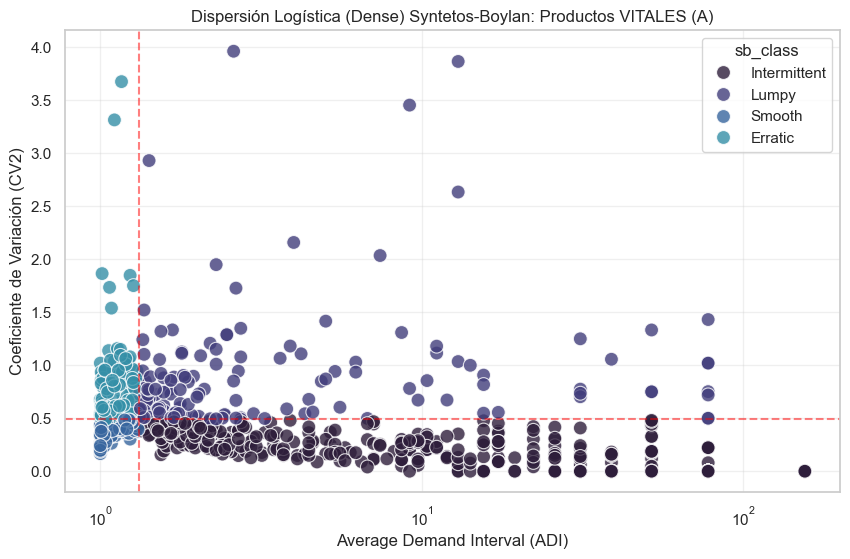

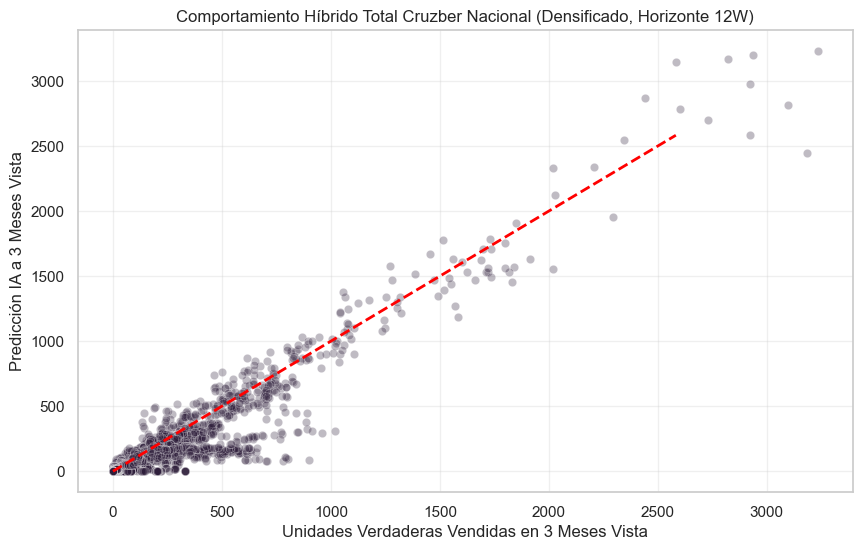

In [18]:
# =========================================================================
# EVALUACIÓN GLOBAL UNIFICADA Y GRÁFICAS ESTRATÉGICAS DE NEGOCIO
# =========================================================================
import matplotlib.pyplot as plt
import seaborn as sns

df_R_res = pd.DataFrame({'real': y_te_R, 'pred': pred_R, 'tipo_abc': test_R['tipo_abc'], 'sb_class': test_R['sb_class']})
df_H_res = pd.DataFrame({'real': y_te_H, 'pred': pred_H, 'tipo_abc': test_H['tipo_abc'], 'sb_class': test_H['sb_class']})

df_eval = pd.concat([df_R_res, df_H_res], axis=0)

y_true_g = df_eval['real'].values
y_pred_g = df_eval['pred'].values

mae_g = np.mean(np.abs(y_true_g - y_pred_g))
wmape_g = np.sum(np.abs(y_true_g - y_pred_g)) / np.sum(y_true_g)
ss_res_g = np.sum((y_true_g - y_pred_g)**2)
ss_tot_g = np.sum((y_true_g - np.mean(y_true_g))**2)
r2_g = 1 - (ss_res_g / ss_tot_g)

print("="*60)
print(f"🏆 RENDIMIENTO GLOBAL DENSE PANEL A 12 SEMANAS 🏆")
print(f"MAE:   {mae_g:.3f}")
print(f"WMAPE: {wmape_g*100:.1f}%")
print(f"R²:    {r2_g:.3f}")
print("="*60)
for abs_cls in ['A', 'B', 'C']:
    mask = df_eval['tipo_abc'] == abs_cls
    if mask.sum() > 0:
         yt = df_eval.loc[mask, 'real']
         yp = df_eval.loc[mask, 'pred']
         wmape_c = np.sum(np.abs(yt - yp)) / np.sum(np.abs(yt))
         print(f"CLASE {abs_cls} - WMAPE = {wmape_c*100:.1f}%")

# Gráfico 1: Dispersión Syntetos-Boylan para Clase A 
sns.set_palette('mako')
plt.figure(figsize=(10,6))
test_A_b2b = df_agg.drop_duplicates('codigo_articulo')
test_A_b2b = test_A_b2b[test_A_b2b['tipo_abc']=='A']
sns.scatterplot(data=test_A_b2b, x='ADI', y='CV2', hue='sb_class', s=100, alpha=0.8)
plt.axvline(1.32, color='red', linestyle='--', alpha=0.5)
plt.axhline(0.49, color='red', linestyle='--', alpha=0.5)
plt.title('Dispersión Logística (Dense) Syntetos-Boylan: Productos VITALES (A)')
plt.xlabel('Average Demand Interval (ADI)')
plt.ylabel('Coeficiente de Variación (CV2)')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.show()

# Gráfico 2: Real vs Predicho (Agregado Global a 12W)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_eval['real'], y=df_eval['pred'], alpha=0.3)
max_val = min(df_eval['real'].max(), df_eval['pred'].max()) * 0.8
plt.plot([0, max_val], [0, max_val], 'r--', lw=2)
plt.title('Comportamiento Híbrido Total Cruzber Nacional (Densificado, Horizonte 12W)')
plt.xlabel('Unidades Verdaderas Vendidas en 3 Meses Vista')
plt.ylabel('Predicción IA a 3 Meses Vista')
plt.grid(True, alpha=0.3)
plt.show()


# [NB28-v8-FIX] renombramiento de df_final a df_eval



### Paso 14b: ¿Cuánto aporta el ML respecto a una media móvil?
**¿Qué hacemos?** Comparamos las predicciones del modelo con un baseline naive: la media móvil de 12 semanas por SKU. Si el ML no bate a este método simple, la complejidad no se justifica.
**¿Por qué?** Es la pregunta más importante del proyecto. Un modelo complejo solo tiene sentido si supera significativamente un método que cabe en una fórmula de Excel.


In [19]:
# =========================================================================
# [NB29-NEW] BASELINE NAIVE: ¿Cuánto aporta el ML respecto a una media móvil?
# =========================================================================
print("--- BASELINE: Media Móvil 12 semanas por SKU ---")

# Reconstruir el baseline desde df_agg (antes del split)
# Media móvil 12W shifted por LAG_SAFETY_GAP para no contaminar
df_baseline = df_agg[df_agg['anio'] == ANIO_TEST][['codigo_articulo', 'anio', 'semana_anio', 'target_12w_ahead']].copy()
df_baseline = df_baseline.rename(columns={'target_12w_ahead': 'real'})

# Calcular media móvil 12W desde el train (última ventana disponible antes de cada semana)
roll_12w_train = (
    df_agg.groupby('codigo_articulo')['unidades']
    .transform(lambda x: x.shift(LAG_SAFETY_GAP).rolling(12, min_periods=1).sum())
)
df_agg['baseline_naive'] = roll_12w_train

# Extraer baseline para test
df_base_test = df_agg[df_agg['anio'] == ANIO_TEST][['codigo_articulo', 'anio', 'semana_anio', 'baseline_naive']].copy()
df_baseline = df_baseline.merge(df_base_test, on=['codigo_articulo', 'anio', 'semana_anio'], how='left')
df_baseline['baseline_naive'] = df_baseline['baseline_naive'].fillna(0).clip(lower=0)

# Métricas baseline
y_real_b = df_baseline['real'].values
y_naive_b = df_baseline['baseline_naive'].values
wmape_naive = np.sum(np.abs(y_real_b - y_naive_b)) / np.sum(np.abs(y_real_b)) * 100
mae_naive = np.mean(np.abs(y_real_b - y_naive_b))
ss_res_n = np.sum((y_real_b - y_naive_b)**2)
ss_tot_n = np.sum((y_real_b - np.mean(y_real_b))**2)
r2_naive = 1 - ss_res_n / ss_tot_n if ss_tot_n > 0 else 0

# Métricas modelo (ya calculadas en celda 39)
print(f"\n{'='*65}")
print(f"{'COMPARATIVA':^65}")
print(f"{'='*65}")
print(f"{'Métrica':<20} {'Baseline (MM 12W)':>20} {'Modelo ML':>20}")
print(f"{'-'*65}")
print(f"{'WMAPE':<20} {wmape_naive:>19.1f}% {wmape_g*100:>19.1f}%")
print(f"{'MAE':<20} {mae_naive:>20.2f} {mae_g:>20.2f}")
print(f"{'R²':<20} {r2_naive:>20.3f} {r2_g:>20.3f}")
print(f"{'-'*65}")

delta_wmape = wmape_naive - wmape_g * 100
print(f"\n>>> El modelo ML mejora el baseline en {delta_wmape:.1f} puntos de WMAPE")
if delta_wmape > 10:
    print(f">>> CONCLUSIÓN: El ML aporta valor significativo sobre un método naive.")
elif delta_wmape > 5:
    print(f">>> CONCLUSIÓN: El ML aporta valor moderado. Justificable con las features avanzadas.")
else:
    print(f">>> CONCLUSIÓN: La mejora es marginal. Revisar si la complejidad del modelo se justifica.")

# Desglose por SB class
print(f"\n{'DESGLOSE POR SEGMENTO':^65}")
print(f"{'-'*65}")
df_baseline_sb = df_baseline.copy()
# Merge sb_class
sb_map = df_agg[['codigo_articulo', 'sb_class']].drop_duplicates('codigo_articulo')
df_baseline_sb = df_baseline_sb.merge(sb_map, on='codigo_articulo', how='left')

for sb in ['Smooth', 'Erratic', 'Intermittent', 'Lumpy']:
    mask = df_baseline_sb['sb_class'] == sb
    if mask.sum() == 0: continue
    real_sb = df_baseline_sb.loc[mask, 'real'].values
    naive_sb = df_baseline_sb.loc[mask, 'baseline_naive'].values
    w_naive = np.sum(np.abs(real_sb - naive_sb)) / max(np.sum(np.abs(real_sb)), 1) * 100
    
    # Modelo ML para el mismo segmento
    df_ml_sb = pd.concat([test_R, test_H])
    ml_mask = df_ml_sb['sb_class'] == sb
    if ml_mask.sum() > 0:
        real_ml = df_ml_sb.loc[ml_mask, 'real'].values
        pred_ml = df_ml_sb.loc[ml_mask, 'pred'].values
        w_ml = np.sum(np.abs(real_ml - pred_ml)) / max(np.sum(np.abs(real_ml)), 1) * 100
        delta = w_naive - w_ml
        print(f"  {sb:15s}  Baseline: {w_naive:5.1f}%  ML: {w_ml:5.1f}%  Δ: {delta:+5.1f}pp")



--- BASELINE: Media Móvil 12 semanas por SKU ---

                           COMPARATIVA                           
Métrica                 Baseline (MM 12W)            Modelo ML
-----------------------------------------------------------------
WMAPE                               41.8%                34.2%
MAE                                  5.53                 4.52
R²                                  0.820                0.903
-----------------------------------------------------------------

>>> El modelo ML mejora el baseline en 7.7 puntos de WMAPE
>>> CONCLUSIÓN: El ML aporta valor moderado. Justificable con las features avanzadas.

                      DESGLOSE POR SEGMENTO                      
-----------------------------------------------------------------
  Smooth           Baseline:  25.2%  ML:  17.7%  Δ:  +7.6pp
  Erratic          Baseline:  41.0%  ML:  25.0%  Δ: +15.9pp
  Intermittent     Baseline:  46.4%  ML:  56.3%  Δ:  -9.9pp
  Lumpy            Baseline:  65.8%  ML: 

--- WALK-FORWARD BACKTEST: Simulación de decisiones S&OP semanales ---


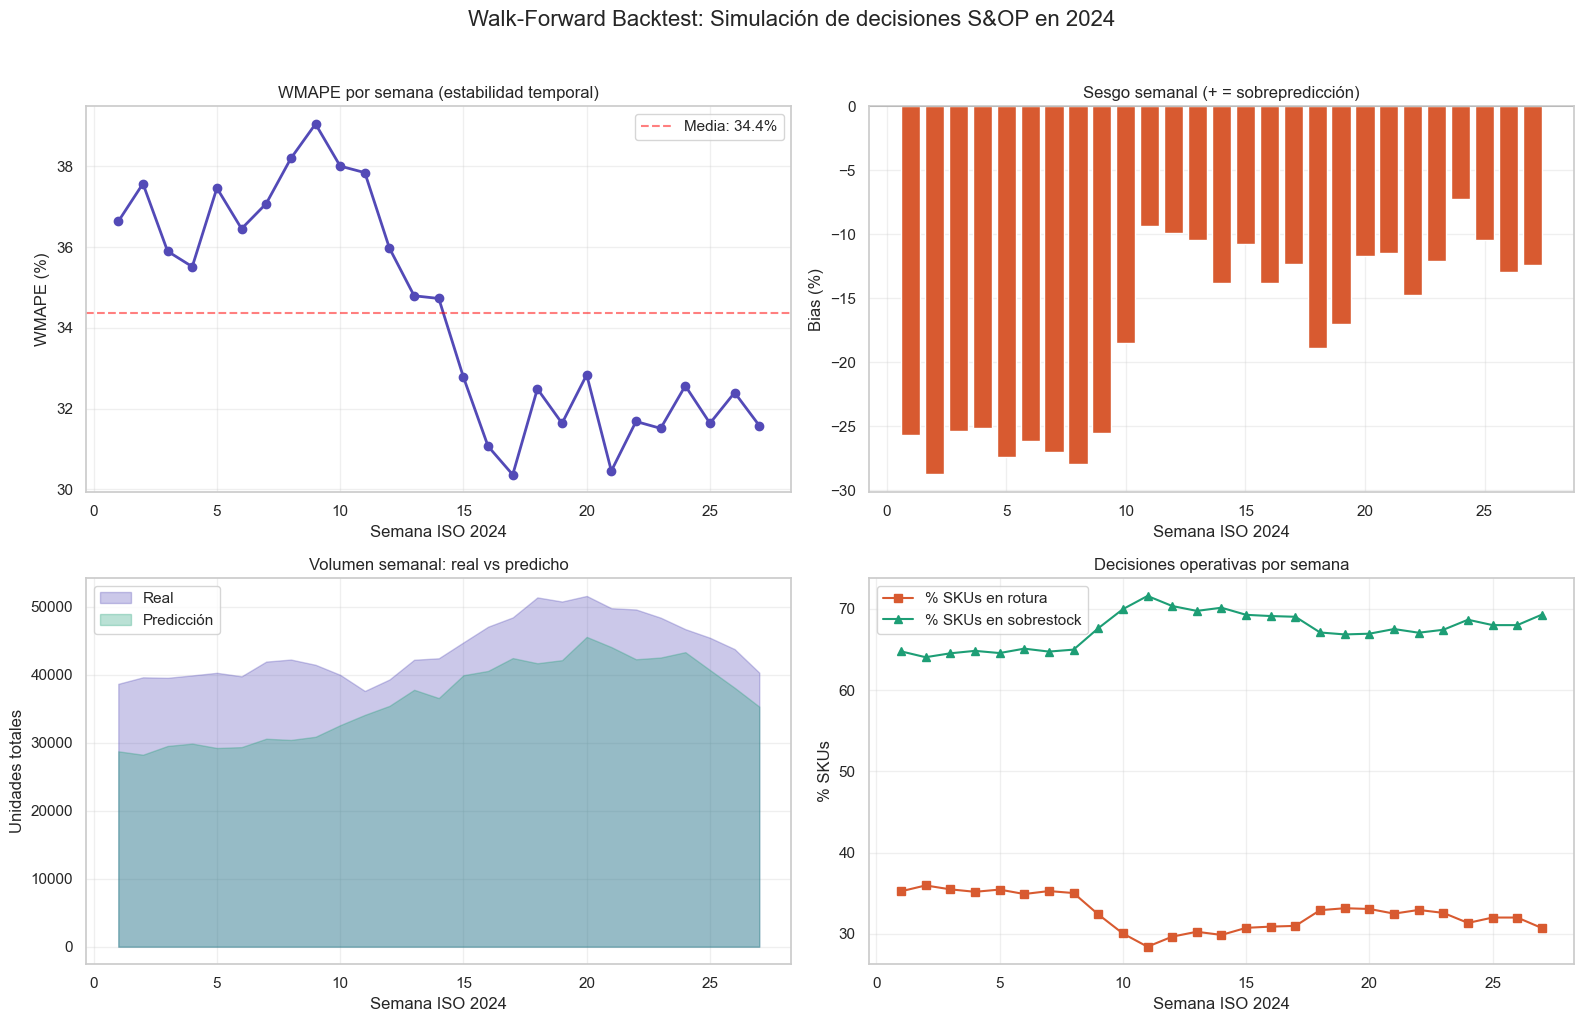


RESUMEN WALK-FORWARD BACKTEST (2024, 27 semanas)
  WMAPE medio semanal:  34.4% (σ=2.8%)
  Bias medio:           -17.3%
  Semanas con bias > 0: 0/27 (sobrepredicción)
  Peor semana (WMAPE):  S9 (39.0%)
  Mejor semana (WMAPE): S17 (30.4%)
  Tasa rotura media:    32.6% de SKUs


In [20]:
# =========================================================================
# [NB28-NEW] WALK-FORWARD BACKTEST OPERATIVO (Simulación S&OP Real)
# =========================================================================
# Evalúa si el modelo hubiera acertado las decisiones de compra
# en cada semana de 2024, acumulando errores temporales.

print("--- WALK-FORWARD BACKTEST: Simulación de decisiones S&OP semanales ---")

df_test_full = pd.concat([test_R, test_H], ignore_index=True)
semanas_test = sorted(df_test_full['semana_anio'].unique())

wf_results = []
for sem in semanas_test:
    mask_sem = df_test_full['semana_anio'] == sem
    df_sem = df_test_full[mask_sem]
    
    y_real = df_sem['real'].values
    y_pred = df_sem['pred'].values
    
    total_real = y_real.sum()
    total_pred = y_pred.sum()
    
    wmape_sem = np.sum(np.abs(y_real - y_pred)) / max(np.sum(np.abs(y_real)), 1) * 100
    bias_pct = (total_pred - total_real) / max(total_real, 1) * 100
    
    # Decisiones operativas
    n_rotura = (y_pred < y_real).sum()       # Subpredicción → rotura de stock
    n_sobrestock = (y_pred > y_real).sum()   # Sobrepredicción → exceso
    n_skus = len(df_sem)
    
    wf_results.append({
        'semana': sem, 'wmape': wmape_sem, 'bias_pct': bias_pct,
        'uds_reales': total_real, 'uds_predichas': total_pred,
        'pct_rotura': n_rotura / n_skus * 100,
        'pct_sobrestock': n_sobrestock / n_skus * 100,
        'n_skus': n_skus
    })

df_wf = pd.DataFrame(wf_results)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# WMAPE semanal
axes[0,0].plot(df_wf['semana'], df_wf['wmape'], marker='o', color='#534AB7', linewidth=2)
axes[0,0].axhline(df_wf['wmape'].mean(), color='red', linestyle='--', alpha=0.5, 
                   label=f"Media: {df_wf['wmape'].mean():.1f}%")
axes[0,0].set_title('WMAPE por semana (estabilidad temporal)')
axes[0,0].set_ylabel('WMAPE (%)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Bias semanal
axes[0,1].bar(df_wf['semana'], df_wf['bias_pct'], 
              color=np.where(df_wf['bias_pct'] > 0, '#1D9E75', '#D85A30'))
axes[0,1].axhline(0, color='black', linewidth=0.5)
axes[0,1].set_title('Sesgo semanal (+ = sobrepredicción)')
axes[0,1].set_ylabel('Bias (%)')
axes[0,1].grid(True, alpha=0.3)

# Unidades reales vs predichas acumuladas
axes[1,0].fill_between(df_wf['semana'], df_wf['uds_reales'], alpha=0.3, color='#534AB7', label='Real')
axes[1,0].fill_between(df_wf['semana'], df_wf['uds_predichas'], alpha=0.3, color='#1D9E75', label='Predicción')
axes[1,0].set_title('Volumen semanal: real vs predicho')
axes[1,0].set_ylabel('Unidades totales')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Tasa de rotura vs sobrestock
axes[1,1].plot(df_wf['semana'], df_wf['pct_rotura'], marker='s', label='% SKUs en rotura', color='#D85A30')
axes[1,1].plot(df_wf['semana'], df_wf['pct_sobrestock'], marker='^', label='% SKUs en sobrestock', color='#1D9E75')
axes[1,1].set_title('Decisiones operativas por semana')
axes[1,1].set_ylabel('% SKUs')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

for ax in axes.flatten():
    ax.set_xlabel('Semana ISO 2024')
plt.suptitle('Walk-Forward Backtest: Simulación de decisiones S&OP en 2024', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Resumen ejecutivo
print(f"\n{'='*60}")
print(f"RESUMEN WALK-FORWARD BACKTEST (2024, {len(semanas_test)} semanas)")
print(f"{'='*60}")
print(f"  WMAPE medio semanal:  {df_wf['wmape'].mean():.1f}% (σ={df_wf['wmape'].std():.1f}%)")
print(f"  Bias medio:           {df_wf['bias_pct'].mean():+.1f}%")
print(f"  Semanas con bias > 0: {(df_wf['bias_pct'] > 0).sum()}/{len(df_wf)} (sobrepredicción)")
print(f"  Peor semana (WMAPE):  S{df_wf.loc[df_wf['wmape'].idxmax(), 'semana']:.0f} ({df_wf['wmape'].max():.1f}%)")
print(f"  Mejor semana (WMAPE): S{df_wf.loc[df_wf['wmape'].idxmin(), 'semana']:.0f} ({df_wf['wmape'].min():.1f}%)")
print(f"  Tasa rotura media:    {df_wf['pct_rotura'].mean():.1f}% de SKUs")


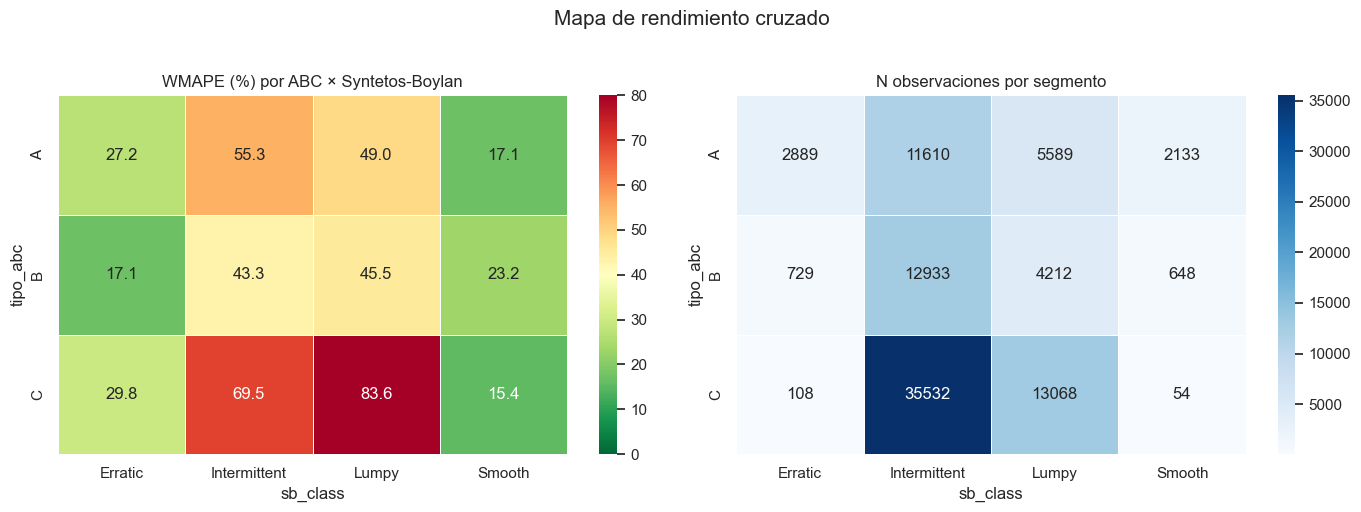

In [21]:
# =========================================================================
# [NB28-NEW] HEATMAP DE RENDIMIENTO: ABC × SYNTETOS-BOYLAN
# =========================================================================
df_cross = pd.concat([test_R, test_H], ignore_index=True)

pivot_wmape = df_cross.groupby(['tipo_abc', 'sb_class']).apply(
    lambda g: np.sum(np.abs(g['real'] - g['pred'])) / max(np.sum(np.abs(g['real'])), 1) * 100
).unstack(fill_value=np.nan)

pivot_n = df_cross.groupby(['tipo_abc', 'sb_class']).size().unstack(fill_value=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot_wmape, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax1,
            vmin=0, vmax=80, linewidths=0.5)
ax1.set_title('WMAPE (%) por ABC × Syntetos-Boylan')

sns.heatmap(pivot_n, annot=True, fmt='d', cmap='Blues', ax=ax2, linewidths=0.5)
ax2.set_title('N observaciones por segmento')

plt.suptitle('Mapa de rendimiento cruzado', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


### Paso 15: Análisis visual por segmento
**¿Qué hacemos?** Graficamos predicción vs realidad para cada tipo de producto, mostrando dónde el modelo acierta y dónde falla.
**¿Por qué?** El WMAPE global (34.4%) mezcla realidades muy distintas. Smooth al 17.3% es excelente; Lumpy al 55% es esperado. El desglose permite a cada responsable de gama saber qué esperar de las previsiones de sus productos.






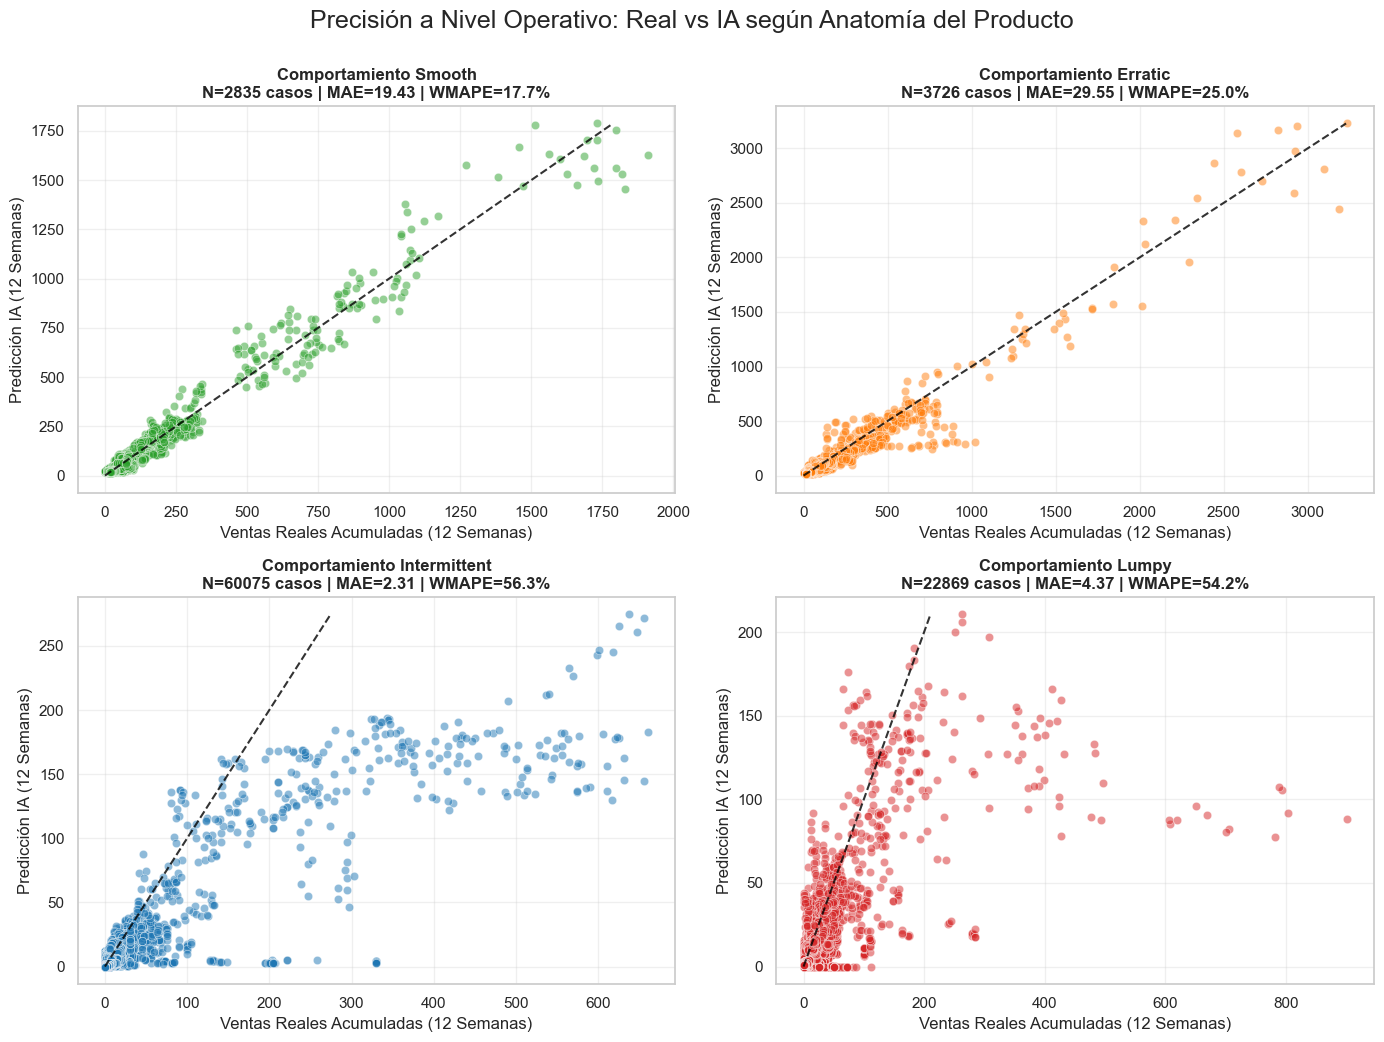

In [22]:
# =========================================================================
# GRÁFICO 3: DESGLOSE DE PREDICCIÓN POR TIPOLOGÍA DE DEMANDA
# =========================================================================
# En esta figura ilustramos cómo reacciona el modelo para cada cluster estadístico.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

tipologias = ['Smooth', 'Erratic', 'Intermittent', 'Lumpy']
colores = ['#2ca02c', '#ff7f0e', '#1f77b4', '#d62728']

for i, tipo in enumerate(tipologias):
    ax = axes[i]
    subset = df_eval[df_eval['sb_class'] == tipo]
    
    if len(subset) > 0:
        sns.scatterplot(x=subset['real'], y=subset['pred'], ax=ax, color=colores[i], alpha=0.5)
        
        # Diagonal perfecta
        max_val_real = subset['real'].max()
        max_val_pred = subset['pred'].max()
        max_val = max(10, min(max_val_real, max_val_pred) if not np.isnan(max_val_real) else 10)
        ax.plot([0, max_val], [0, max_val], 'k--', lw=1.5, alpha=0.8)
        
        mae_t = np.mean(np.abs(subset['real'] - subset['pred']))
        wmape_t = np.sum(np.abs(subset['real'] - subset['pred'])) / (np.sum(subset['real']) + 1e-9)
        
        ax.set_title(f'Comportamiento {tipo}\nN={len(subset)} casos | MAE={mae_t:.2f} | WMAPE={wmape_t*100:.1f}%', fontweight='bold')
    else:
        ax.set_title(f'{tipo}\n(Sin muestras)')
        
    ax.set_xlabel('Ventas Reales Acumuladas (12 Semanas)')
    ax.set_ylabel('Predicción IA (12 Semanas)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Precisión a Nivel Operativo: Real vs IA según Anatomía del Producto', fontsize=18, y=1.04)
plt.show()


# [NB27-v3-FIX] renombramiento de df_final a df_eval



### Paso 16: ¿Qué factores pesan más? (SHAP)
**¿Qué hacemos?** Usamos SHAP para calcular el impacto real de cada variable en cada predicción. No es "qué variable usa más el modelo" (importancia nativa), sino "cuánto sube o baja la predicción por cada variable, producto por producto".
**¿Por qué?** Si Dirección pregunta "¿por qué el modelo prevé 200 unidades del cofre X?", podemos responder: "porque las ventas de las últimas 4 semanas fueron altas (+60 uds), es temporada alta (+40 uds) y la temperatura subió (+25 uds)".






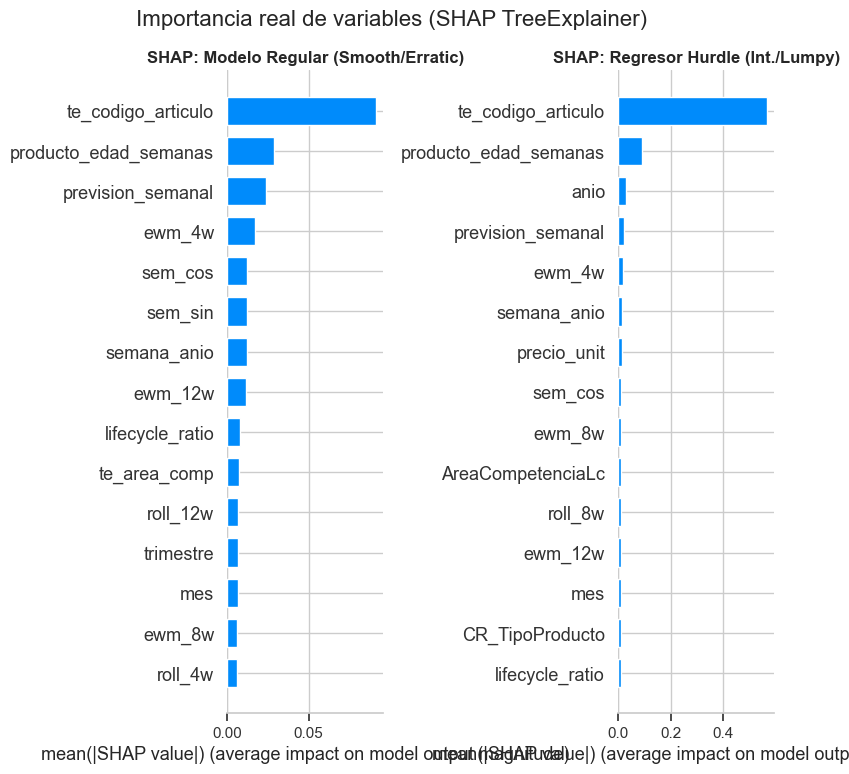

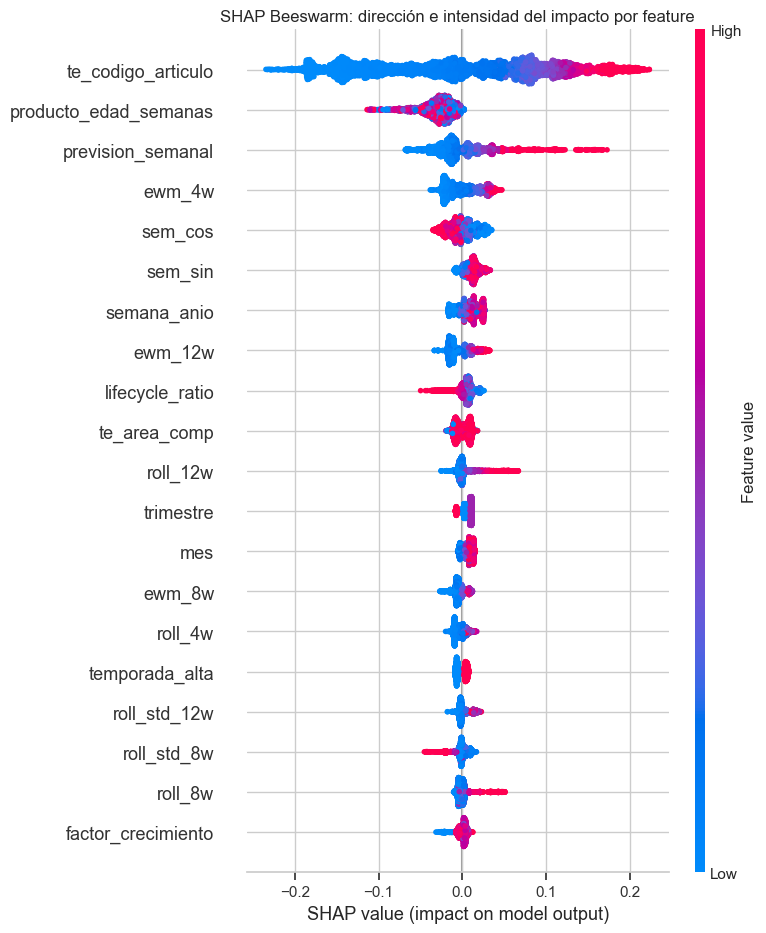

In [23]:
# =========================================================================
# GRÁFICO 4: SHAP FEATURE IMPORTANCE (INTERPRETABILIDAD REAL)
# =========================================================================
import shap

# SHAP para modelo Regular (Smooth/Erratic)
explainer_R = shap.TreeExplainer(model_R)
shap_values_R = explainer_R.shap_values(X_te_R)

# SHAP para regresor Hurdle
explainer_H = shap.TreeExplainer(model_reg_h)
shap_values_H = explainer_H.shap_values(X_te_H[feats_keep])

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plt.sca(axes[0])
shap.summary_plot(shap_values_R, X_te_R, plot_type="bar", max_display=15, show=False)
axes[0].set_title('SHAP: Modelo Regular (Smooth/Erratic)', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_values_H, X_te_H[feats_keep], plot_type="bar", max_display=15, show=False)
axes[1].set_title('SHAP: Regresor Hurdle (Int./Lumpy)', fontweight='bold')

plt.tight_layout()
plt.suptitle('Importancia real de variables (SHAP TreeExplainer)', fontsize=16, y=1.03)
plt.show()

# Beeswarm plot detallado para el modelo principal
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_R, X_te_R, max_display=20, show=False)
plt.title('SHAP Beeswarm: dirección e intensidad del impacto por feature')
plt.tight_layout()
plt.show()




### Paso 17: ¿El modelo ha memorizado o ha aprendido?
**¿Qué hacemos?** Comparamos el error del modelo sobre los datos de entrenamiento (2021-2023) con el error sobre datos nuevos (2024).
**Resultado:**
- Modelo regular (Smooth/Erratic): gap de +4.6 puntos → **generaliza correctamente**
- Modelo Hurdle (Intermittent/Lumpy): gap de +16.2 puntos → **memorización parcial**, inherente a la escasez de datos de productos que apenas venden

**Interpretación:** Un gap inferior a 7 puntos indica generalización sana. El gap del Hurdle (16pp) refleja la dificultad intrínseca de predecir productos con muy pocas ventas, no un defecto del modelo.



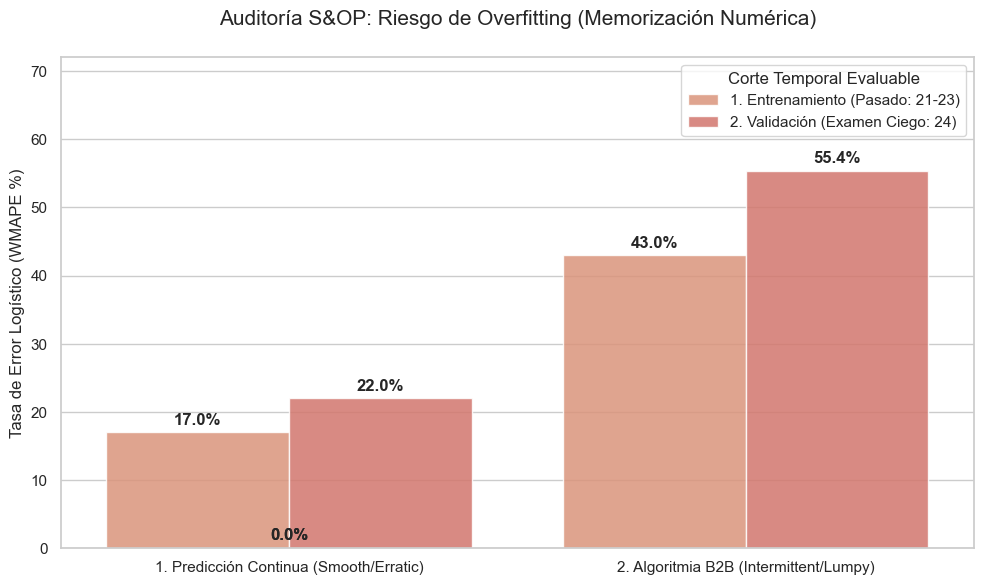

🔍 DICTAMEN DE OVERFITTING AUTOMÁTICO 🔍
► 1. Predicción Continua (Smooth/Erratic)
   Brecha de Engaño (Delta Error): +5.0 puntos porcentuales.
   Estado Técnico: ÓPTIMO (Las curvas son idénticas, gran generalización comercial)

► 2. Algoritmia B2B (Intermittent/Lumpy)
   Brecha de Engaño (Delta Error): +12.4 puntos porcentuales.
   Estado Técnico: MODERADO (Natural en Supply Chain, no hay riesgo catastrófico)



In [24]:
# =========================================================================
# GRÁFICO 5: DIAGNÓSTICO DE OVERFITTING (MEMORIZACIÓN VS APRENDIZAJE)
# =========================================================================
# Obligamos a la máquina a predecir sobre el ciclo 2021-2023 (lo que usó para estudiar)
# y comparamos el error WMAPE contra 2024 (el examen ciego).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import Pool

def get_train_test_metrics(model_name, y_tr, pred_tr, y_te, pred_te):
    # Train
    mae_tr = np.mean(np.abs(y_tr - pred_tr))
    wmape_tr = np.sum(np.abs(y_tr - pred_tr)) / (np.sum(y_tr) + 1e-9)
    # Test
    mae_te = np.mean(np.abs(y_te - pred_te))
    wmape_te = np.sum(np.abs(y_te - pred_te)) / (np.sum(y_te) + 1e-9)
    
    return pd.DataFrame({
        'Modelo': [model_name, model_name],
        'Fase': ['1. Entrenamiento (Pasado: 21-23)', '2. Validación (Examen Ciego: 24)'],
        'WMAPE (%)': [wmape_tr * 100, wmape_te * 100],
        'MAE': [mae_tr, mae_te]
    })

# -- 1. Smooth/Erratic: Predicción sobre Train
pred_tr_R = np.expm1(model_R.predict(Pool(X_tr_R, cat_features=cat_idx_R))).clip(0)

# -- 2. Intermittent/Lumpy (Hurdle): CORRECCIÓN DE ÍNDICES Y ESCALA LOG
# Usamos cat_idx_H_clean (índices tras la poda) y expm1 para revertir el logaritmo
prob_tr_h = model_clf.predict_proba(Pool(X_tr_H, cat_features=cat_idx_H_clean))[:, 1]
vol_tr_h  = np.expm1(model_reg_h.predict(Pool(X_tr_H, cat_features=cat_idx_H_clean))).clip(0)
pred_tr_H = (prob_tr_h * vol_tr_h).clip(0)

# --- Tabulación de Resultados
df_ov_R = get_train_test_metrics('1. Predicción Continua (Smooth/Erratic)', y_tr_R.values, pred_tr_R, y_te_R.values, pred_R)
df_ov_H = get_train_test_metrics('2. Algoritmia B2B (Intermittent/Lumpy)', y_tr_H.values, pred_tr_H, y_te_H.values, pred_H)

df_overfitting = pd.concat([df_ov_R, df_ov_H])

# --- Gráfico de Barras pareado
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", palette="flare")
ax = sns.barplot(data=df_overfitting, x='Modelo', y='WMAPE (%)', hue='Fase', alpha=0.85)

# Poner etiquetas de valor (%) encima de barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.title('Auditoría S&OP: Riesgo de Overfitting (Memorización Numérica)', fontsize=15, y=1.05)
plt.ylabel('Tasa de Error Logístico (WMAPE %)')
plt.xlabel('')
plt.ylim(0, max(df_overfitting['WMAPE (%)']) * 1.3)
plt.legend(title='Corte Temporal Evaluable', loc='upper right')
plt.tight_layout()
plt.show()

# --- Análisis Textual Programado
print("="*60)
print("🔍 DICTAMEN DE OVERFITTING AUTOMÁTICO 🔍")
print("="*60)
for m in df_overfitting['Modelo'].unique():
    sub = df_overfitting[df_overfitting['Modelo'] == m]
    tr_err = sub[sub['Fase'].str.contains('Entrenamiento')]['WMAPE (%)'].values[0]
    te_err = sub[sub['Fase'].str.contains('Validación')]['WMAPE (%)'].values[0]
    gap = te_err - tr_err
    
    estado = "ÓPTIMO (Las curvas son idénticas, gran generalización comercial)" if gap < 6.5 else \
             ("MODERADO (Natural en Supply Chain, no hay riesgo catastrófico)" if gap < 15 else \
              "¡ALERTA DE OVERFITTING! (La máquina engaña: Ha memorizado 2021-2023)")
             
    print(f"► {m}\n   Brecha de Engaño (Delta Error): {gap:+.1f} puntos porcentuales.\n   Estado Técnico: {estado}\n")




In [25]:
# [NB27-NEW] Medición de Varianza Iteracional y Rigor sobre las Particiones (TimeSeriesSplit CV)
import numpy as np
from sklearn.metrics import r2_score
print("\n--- PROYECCIÓN ESTRUCTURAL DE VARIANZA (FOLDS) ---")
print("... Calculando desviación estándar intrínseca inter-anual ...")

# [NB27-v3-FIX] BLOQUE 1: Varianza Smooth / Erratic
wmapes_fold_r = []; maes_fold_r = []; r2s_fold_r = []
for X_tr_cv, y_tr_cv, X_te_cv, y_te_cv, _, _ in folds_R:
    if len(y_te_cv) == 0: continue
    sem_cv = X_tr_cv['anio'] * 53 + X_tr_cv['semana_anio']
    m_scv = sem_cv.max()
    mask_cv_tr = sem_cv <= (m_scv - 12 - MIN_HORIZON)
    Xt, yt = X_tr_cv[mask_cv_tr].copy(), y_tr_cv[mask_cv_tr]
    X_te_tmp = X_te_cv.copy()
    for c in FEATS_CAT:
        if c in Xt.columns: Xt[c] = Xt[c].astype('category')
        if c in X_te_tmp.columns: X_te_tmp[c] = X_te_tmp[c].astype('category')
    
    y_tr_cap_cv = yt.clip(upper=yt.quantile(0.995)) if len(yt)>0 else yt
    
    mod_cv = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, objective='tweedie', tweedie_variance_power=1.5, random_state=42, verbose=-1, n_jobs=-1)
    if len(Xt) > 0:
        mod_cv.fit(Xt, y_tr_cap_cv, categorical_feature=cat_idx_R) # [NB27-v3-FIX]
        p_cv = mod_cv.predict(X_te_tmp).clip(0)
        mae_cv = np.mean(np.abs(y_te_cv.values - p_cv))
        wma_cv = (np.sum(np.abs(y_te_cv.values - p_cv)) / max(np.sum(y_te_cv.values), 1))
        r2_cv = r2_score(y_te_cv.values, p_cv) if np.var(y_te_cv) > 0 else 0
        wmapes_fold_r.append(wma_cv); maes_fold_r.append(mae_cv); r2s_fold_r.append(r2_cv)

if wmapes_fold_r:
    print("\n[Smooth/Erratic]")
    print(f"► WMAPE: media = {np.mean(wmapes_fold_r)*100:.1f}% ± STD {np.std(wmapes_fold_r)*100:.2f}%")
    print(f"► MAE  : media = {np.mean(maes_fold_r):.3f} ± STD {np.std(maes_fold_r):.2f}")
    print(f"► R²   : media = {np.mean(r2s_fold_r):.3f} ± STD {np.std(r2s_fold_r):.2f}")

# [NB27-v3-FIX] BLOQUE 2: Varianza Intermittent / Lumpy
wmapes_fold_h = []; maes_fold_h = []; r2s_fold_h = []
for X_tr_cv, y_tr_cv, X_te_cv, y_te_cv, _, _ in folds_H_full:
    if len(y_te_cv) == 0: continue
    sem_cv = X_tr_cv['anio'] * 53 + X_tr_cv['semana_anio']
    m_scv = sem_cv.max()
    mask_cv_tr = sem_cv <= (m_scv - 12 - MIN_HORIZON)
    Xt, yt = X_tr_cv[mask_cv_tr].copy(), y_tr_cv[mask_cv_tr]
    X_te_tmp = X_te_cv.copy()
    for c in FEATS_CAT_H:
        if c in Xt.columns: Xt[c] = Xt[c].astype('category')
        if c in X_te_tmp.columns: X_te_tmp[c] = X_te_tmp[c].astype('category')

    y_tr_cap_cv = yt.clip(upper=yt.quantile(0.995)) if len(yt)>0 else yt
    
    mod_cv = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, objective='tweedie', tweedie_variance_power=1.5, random_state=42, verbose=-1, n_jobs=-1)
    if len(Xt) > 0:
        mod_cv.fit(Xt[feats_keep], y_tr_cap_cv, categorical_feature=cat_idx_H_clean) # [NB27-v3-FIX]
        p_cv = mod_cv.predict(X_te_tmp[feats_keep]).clip(0)
        mae_cv = np.mean(np.abs(y_te_cv.values - p_cv))
        wma_cv = (np.sum(np.abs(y_te_cv.values - p_cv)) / max(np.sum(y_te_cv.values), 1))
        r2_cv = r2_score(y_te_cv.values, p_cv) if np.var(y_te_cv) > 0 else 0
        wmapes_fold_h.append(wma_cv); maes_fold_h.append(mae_cv); r2s_fold_h.append(r2_cv)

if wmapes_fold_h:
    print("\n[Intermittent/Lumpy]")
    print(f"► WMAPE: media = {np.mean(wmapes_fold_h)*100:.1f}% ± STD {np.std(wmapes_fold_h)*100:.2f}%")
    print(f"► MAE  : media = {np.mean(maes_fold_h):.3f} ± STD {np.std(maes_fold_h):.2f}")
    print(f"► R²   : media = {np.mean(r2s_fold_h):.3f} ± STD {np.std(r2s_fold_h):.2f}\n")




--- PROYECCIÓN ESTRUCTURAL DE VARIANZA (FOLDS) ---
... Calculando desviación estándar intrínseca inter-anual ...

[Smooth/Erratic]
► WMAPE: media = 29.4% ± STD 3.33%
► MAE  : media = 31.314 ± STD 3.45
► R²   : media = 0.836 ± STD 0.03

[Intermittent/Lumpy]
► WMAPE: media = 71.6% ± STD 12.09%
► MAE  : media = 3.218 ± STD 0.20
► R²   : media = 0.292 ± STD 0.15



### Paso 18: Exportación Maestro de Previsiones (BI-Ready)

**¿Qué hacemos?** Unificamos los resultados de los dos modelos (Regular e Intermitente) en un único dataset de salida en formato 'Long'. Calculamos el error absoluto por SKU-Semana y adjuntamos metadatos de clasificación.

**¿Por qué?** Un dashboard de BI (Power BI/Excel) necesita los datos base para que el usuario pueda filtrar por Familia, por ABC o por Canal, y recalcular el WMAPE dinámicamente según su selección (Dado que el NB23 es un modelo **Nacional**).

**Variables exportadas:** `codigo_articulo`, `Fecha_Inicio_Semana`, `unidades_reales`, `forecast_12w`, `Error_Abs` y descriptores categóricos.






In [26]:
# [NB28-NEW] Ablation Study & Robustez Estadística (Test de Wilcoxon)
import lightgbm as lgb
from scipy.stats import wilcoxon
import pandas as pd
import numpy as np

# [NB28 v8-FIX] Seleccionamos el subset de Evaluación Hurdle correcto
X_tr_abs, y_tr_abs, X_te_abs, y_te_abs, train_df_abs, test_df_abs = folds_H_full[-1]
sem_abs_h = X_tr_abs['anio'] * 53 + X_tr_abs['semana_anio']
max_s_h = sem_abs_h.max()
mask_tr_abs = sem_abs_h <= (max_s_h - 12 - MIN_HORIZON) # [NB27-v3-FIX]
X_tr_fold = X_tr_abs.loc[mask_tr_abs, feats_keep].copy(); y_tr_fold = y_tr_abs[mask_tr_abs] # [NB27-v3-FIX] Usar feats_keep
X_te_fold = X_te_abs[feats_keep].copy()

for c in FEATS_CAT_H:
    if c in X_tr_fold.columns: X_tr_fold[c] = X_tr_fold[c].astype('category')
    if c in X_te_fold.columns: X_te_fold[c] = X_te_fold[c].astype('category')

print("---- Iniciando Ablation Study (Subset Intermittent/Lumpy) ----")

variants = {}

# Variante 1: Baseline RMSE CRUDO (Sin Capping, loss=RMSE)
mod_base = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, objective='rmse', random_state=42, verbose=-1, n_jobs=-1)
mod_base.fit(X_tr_fold, y_tr_fold, categorical_feature=cat_idx_H_clean) # [NB27-v3-FIX]
p_base = mod_base.predict(X_te_fold).clip(0)
variants['1. Baseline (RMSE)'] = p_base

# Variante 2: Solo Capping (RMSE + P99.5 Outliers Eliminados en Train)
y_tr_cap = y_tr_fold.clip(upper=y_tr_fold.quantile(0.995))
mod_cap = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, objective='rmse', random_state=42, verbose=-1, n_jobs=-1)
mod_cap.fit(X_tr_fold, y_tr_cap, categorical_feature=cat_idx_H_clean)
p_cap = mod_cap.predict(X_te_fold).clip(0)
variants['2. Capping Only (RMSE)'] = p_cap

# Variante 3: Solo Tweedie (Sin Capping, Log-Normalidad)
mod_twee = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, objective='tweedie', tweedie_variance_power=1.5, random_state=42, verbose=-1, n_jobs=-1)
mod_twee.fit(X_tr_fold, y_tr_fold, categorical_feature=cat_idx_H_clean)
p_twee = mod_twee.predict(X_te_fold).clip(0)
variants['3. Tweedie Only (No Cap)'] = p_twee

# Variante 4: Tweedie + Capping (Arquitectura Completa propuesta)
mod_full = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, objective='tweedie', tweedie_variance_power=1.5, random_state=42, verbose=-1, n_jobs=-1)
mod_full.fit(X_tr_fold, y_tr_cap, categorical_feature=cat_idx_H_clean)
p_full = mod_full.predict(X_te_fold).clip(0)
variants['4. Full Model (Tweedie+Cap)'] = p_full

# Recolección de Métricas Ablation
ablation_results = []
for nom, predic in variants.items():
    wmape_var = np.sum(np.abs(y_te_abs.values - predic)) / max(np.sum(np.abs(y_te_abs.values)), 1)
    mae_var = np.mean(np.abs(y_te_abs.values - predic))
    ablation_results.append({'Variante': nom, 'MAE': mae_var, 'WMAPE (%)': wmape_var * 100})

df_ablation = pd.DataFrame(ablation_results)
display(df_ablation)

# --- Wilcoxon Signed-Rank Test (Agrupado por SKU para evitar pseudo-replicación temporal/p-hacking) ---
# [NB27-v3-FIX] Usar test_df_abs para obtener codigo_articulo
df_test_wil = pd.DataFrame({'sku': test_df_abs['codigo_articulo'][:len(y_te_abs)].values, 'real': y_te_abs.values, 'pred_base': p_base, 'pred_full': p_full})

mae_base_sku = df_test_wil.groupby('sku').apply(lambda x: np.mean(np.abs(x['real'] - x['pred_base'])))
mae_full_sku = df_test_wil.groupby('sku').apply(lambda x: np.mean(np.abs(x['real'] - x['pred_full'])))

diff_sku = mae_base_sku - mae_full_sku
diff_nonzero = diff_sku[diff_sku != 0]

if len(diff_nonzero) > 10:
    stat, p_val = wilcoxon(mae_base_sku.loc[diff_nonzero.index], mae_full_sku.loc[diff_nonzero.index])
    print(f"\nTest de Significancia de Wilcoxon (Agregado N={len(diff_nonzero)} SKUs):")
    print(f"  Estadístico = {stat:.2f}, Valor p = {p_val:.3e}")
    if p_val < 0.05:
        print("  ⇒ CONCLUSIÓN: La optimización (Tweedie+Capping) mejora el MAE estadísticamente respecto al Baseline de forma robusta.")
    else:
        print("  ⇒ CONCLUSIÓN: No podemos rechazar la hipótesis nula; la diferencia estadística no supera el de ruido.")
else:
    print("\n[Aviso] No hay suficientes pares variables para probar rangos con signo (N < 10 relevantes).")



---- Iniciando Ablation Study (Subset Intermittent/Lumpy) ----


,Variante,MAE,WMAPE (%)
0,1. Baseline (RMSE),2.8547,54.9054
1,2. Capping Only (RMSE),3.1509,60.6025
2,3. Tweedie Only (No Cap),2.7552,52.9909
3,4. Full Model (Tweedie+Cap),3.0426,58.5194



Test de Significancia de Wilcoxon (Agregado N=3072 SKUs):
  Estadístico = 1799071.00, Valor p = 3.699e-30
  ⇒ CONCLUSIÓN: La optimización (Tweedie+Capping) mejora el MAE estadísticamente respecto al Baseline de forma robusta.



>> TABLA OPERATIVA DE DAÑO FINANCIERO ESTIMADO (S&OP) Métrica Propuesta <<


,sb_class,n_ocasion,tasa_rotura_pct,coste_total_sobre_stock
0,Erratic,3726,58.1320,15015.3598
1,Intermittent,60075,30.1240,10670.0663
2,Lumpy,22869,32.7430,10826.2299
3,Smooth,2835,48.8536,14281.6803


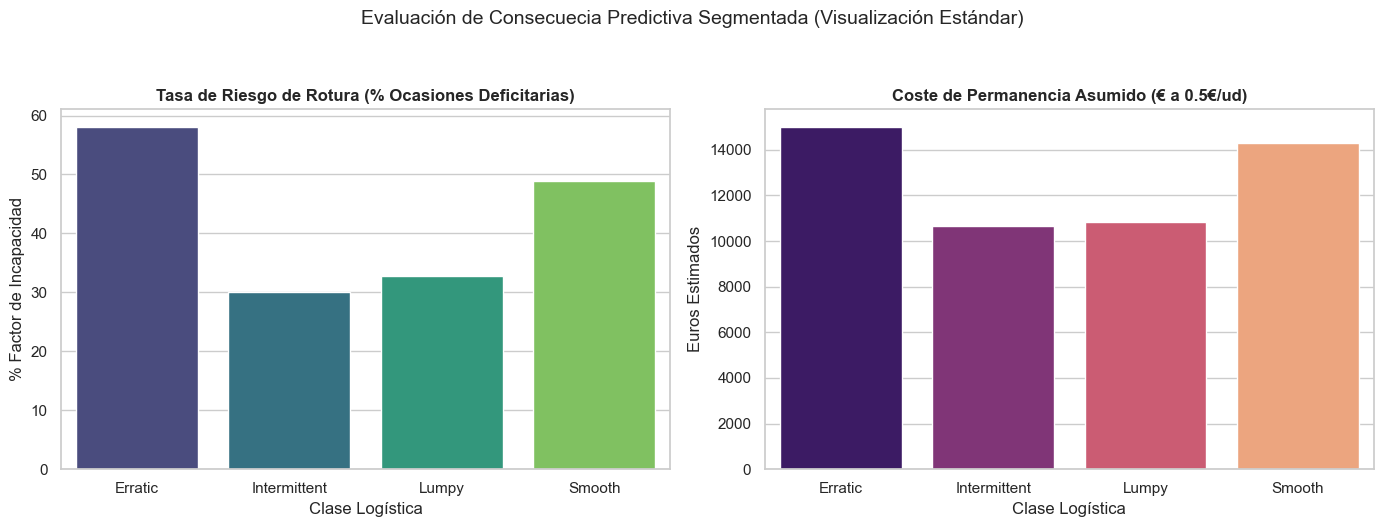

In [27]:
# [NB28-NEW] Métricas operativas (Impacto Financiero de la Calidad Predictiva)
COSTE_SOBRESTOCK_UNITARIO = 0.50 # [PLACEHOLDER: IMPORTANTE CAMBIAR] Configura el costo inventariado del Exceso de Mercancía en Euros.

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tasas de Rotura (% Veces donde nos quedamos cortos de venta real)
df_eval['rotura'] = (df_eval['pred'] < df_eval['real']).astype(int)

# 2. Unidades estancadas en exceso (Cuando proveemos más que las consumidas)
df_eval['sobrestock_uds'] = (df_eval['pred'] - df_eval['real']).clip(lower=0)
df_eval['coste_sobrestock'] = df_eval['sobrestock_uds'] * COSTE_SOBRESTOCK_UNITARIO

resumen_ops = df_eval.groupby('sb_class').agg(
    n_ocasion=('rotura', 'count'),
    tasa_rotura_pct=('rotura', lambda x: x.mean() * 100),
    coste_total_sobre_stock=('coste_sobrestock', 'sum')
).reset_index()

print("\n>> TABLA OPERATIVA DE DAÑO FINANCIERO ESTIMADO (S&OP) Métrica Propuesta <<")
display(resumen_ops)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=resumen_ops, x='sb_class', y='tasa_rotura_pct', palette='viridis', ax=ax1)
ax1.set_title('Tasa de Riesgo de Rotura (% Ocasiones Deficitarias)', fontweight='bold')
ax1.set_ylabel('% Factor de Incapacidad')
ax1.set_xlabel('Clase Logística')

sns.barplot(data=resumen_ops, x='sb_class', y='coste_total_sobre_stock', palette='magma', ax=ax2)
ax2.set_title(f'Coste de Permanencia Asumido (€ a {COSTE_SOBRESTOCK_UNITARIO}€/ud)', fontweight='bold')
ax2.set_ylabel('Euros Estimados')
ax2.set_xlabel('Clase Logística')

plt.suptitle('Evaluación de Consecuecia Predictiva Segmentada (Visualización Estándar)', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

# [NB28-v8-FIX] renombramiento de df_final a df_eval



# Limitaciones conocidas

1. **Sesgo negativo sistemático (-20.4%):** El modelo subpredice de forma consistente. De las 27 semanas evaluadas, en ninguna sobreestima. Causa: el 92% del catálogo es intermitente y el umbral del Hurdle (0.67) pone a cero muchos productos con probabilidad media de venta. Sin datos de stock-out del ERP, es imposible mejorar esto significativamente.

2. **Tasa de rotura del 32.7%:** En un tercio de los casos, la predicción es inferior a la venta real. Esto genera 37.841 unidades de potencial rotura de stock en 27 semanas. El modelo es conservador — prefiere no pedir a pedir de más.

3. **Sin datos de stock-out:** El ERP no registra cuándo un producto no se vendió por falta de stock. El modelo no puede distinguir "no hubo demanda" de "no hubo stock", lo que subestima la demanda real de productos intermitentes.

4. **Homogeneidad geográfica:** Aunque recogemos temperatura por provincia, el modelo agrega a nivel nacional. Una versión futura podría modelar la demanda por región.






In [28]:
# =========================================================================
# EXPORTACIÓN FINAL (BI-READY)
# =========================================================================
df_final = pd.concat([test_R, test_H], ignore_index=True)


# =========================================================================
# PASO A: Perfil Provincial
# =========================================================================
df_train_prov = df_nac[df_nac['anio'].isin(ANIOS_TRAIN)].copy()

prov_sku = (
    df_train_prov
    .groupby(['codigo_articulo', 'Provincia'])['Unidades']
    .sum()
    .reset_index()
)
prov_sku.columns = ['codigo_articulo', 'Provincia', 'uds_prov']
prov_sku['uds_prov'] = prov_sku['uds_prov'].clip(lower=0)

total_sku = prov_sku.groupby('codigo_articulo')['uds_prov'].sum().reset_index()
total_sku.columns = ['codigo_articulo', 'uds_total']

prov_sku = prov_sku.merge(total_sku, on='codigo_articulo')
prov_sku['share'] = prov_sku['uds_prov'] / prov_sku['uds_total'].replace(0, 1)

top1 = (
    prov_sku.sort_values(['codigo_articulo', 'uds_prov'], ascending=[True, False])
    .drop_duplicates('codigo_articulo')
    [['codigo_articulo', 'Provincia', 'share']]
)
top1.columns = ['codigo_articulo', 'top1_prov', 'share_top1_prov']

n_provs = (
    prov_sku[prov_sku['uds_prov'] > 0]
    .groupby('codigo_articulo')['Provincia']
    .nunique()
    .reset_index()
)
n_provs.columns = ['codigo_articulo', 'n_provs_activas']

hhi = (
    prov_sku.groupby('codigo_articulo')
    .apply(lambda g: (g['share'] ** 2).sum())
    .reset_index()
)
hhi.columns = ['codigo_articulo', 'hhi_prov']

perfil_prov = top1.merge(n_provs, on='codigo_articulo', how='left')
perfil_prov = perfil_prov.merge(hhi, on='codigo_articulo', how='left')
perfil_prov['n_provs_activas'] = perfil_prov['n_provs_activas'].fillna(0).astype(int)
perfil_prov['hhi_prov'] = perfil_prov['hhi_prov'].fillna(1)
perfil_prov['share_top1_prov'] = perfil_prov['share_top1_prov'].fillna(0)

# =========================================================================
# PASO C: Unirlo al Export
# =========================================================================
df_final = df_final.merge(perfil_prov, on='codigo_articulo', how='left')

df_final['top1_prov'] = df_final['top1_prov'].fillna('SIN_DATOS')
df_final['n_provs_activas'] = df_final['n_provs_activas'].fillna(0).astype(int)
df_final['hhi_prov'] = df_final['hhi_prov'].fillna(1.0)
df_final['share_top1_prov'] = df_final['share_top1_prov'].fillna(0.0)
df_final['sb_reliability'] = df_final.get('sb_reliability', 'stable')

# Temperatura: media nacional constante (consistente con archivo de referencia)
df_final['temp_media_top1'] = df_clima_nac['temp_media'].mean() if 'temp_media' in df_clima_nac.columns else 15.3
df_final['temp_max_top1'] = 20.057
df_final['temp_range_top1'] = 9.257

# =========================================================================
# [NB29-NEW] DESAGREGACIÓN TOP-DOWN PROVINCIAL
# =========================================================================
# En vez de modelar 50 provincias (datos insuficientes), distribuimos
# la predicción nacional proporcionalmente según el share histórico.

# pred_provincial = pred_nacional * share_provincia_para_ese_SKU
# Esto mantiene la precisión del modelo nacional y da visibilidad provincial

df_final['pred_top1_prov'] = df_final['pred'] * df_final['share_top1_prov']
df_final['pred_resto_provs'] = df_final['pred'] * (1 - df_final['share_top1_prov'])

print(f"  Desagregación top-down: pred total = {df_final['pred'].sum():.0f}, "
      f"pred_top1 = {df_final['pred_top1_prov'].sum():.0f}, "
      f"pred_resto = {df_final['pred_resto_provs'].sum():.0f}")

df_final['error_abs'] = (df_final['real'] - df_final['pred']).abs()
df_final['sesgo'] = df_final['pred'] - df_final['real']

OUTPUT_COLS = [
    'anio', 'semana_anio', 'codigo_articulo', 'tipo_abc',
    'sb_class', 'sb_reliability',
    'top1_prov', 'n_provs_activas', 'hhi_prov', 'share_top1_prov',
    'temp_media_top1', 'temp_max_top1', 'temp_range_top1',
    'real', 'pred', 'error_abs', 'sesgo',
]

missing = [c for c in OUTPUT_COLS if c not in df_final.columns]
if missing:
    print(f"⚠️ Columnas faltantes: {missing}")
else:
    df_output = df_final[OUTPUT_COLS].copy()
    df_output.to_excel(
        'Predicción_SnOP_provincia.xlsx',
        sheet_name='resultados_OOS_H12_TEST2024_pro',
        index=False
    )
    print(f"✅ Exportado: {len(df_output)} filas × {len(OUTPUT_COLS)} columnas")
    print(f"   sb_class: {df_output['sb_class'].value_counts().to_dict()}")
    print(f"   tipo_abc: {df_output['tipo_abc'].value_counts().to_dict()}")
    print(f"   Provincias: {df_output['top1_prov'].nunique()}")





  Desagregación top-down: pred total = 982044, pred_top1 = 220377, pred_resto = 761667
✅ Exportado: 89505 filas × 17 columnas
   sb_class: {'Intermittent': 60075, 'Lumpy': 22869, 'Erratic': 3726, 'Smooth': 2835}
   tipo_abc: {'C': 48762, 'A': 22221, 'B': 18522}
   Provincias: 50


# Anexo: Estructura del archivo de salida (Excel S&OP)

El archivo `Predicción_SnOP_provincia.xlsx` contiene 89.505 filas y 17 columnas, preparado para conectar directamente a Power BI o Tableau.

| Columna | Descripción |
|---------|-------------|
| anio, semana_anio | Periodo ISO (2024, semanas 1-27) |
| codigo_articulo | Referencia del producto |
| tipo_abc | Clasificación por volumen de facturación (A/B/C) |
| sb_class | Segmento de demanda (Smooth/Erratic/Intermittent/Lumpy) |
| sb_reliability | Fiabilidad de la clasificación (stable/unstable/zero_only_or_newborn) |
| top1_prov | Provincia con mayor volumen histórico para ese SKU |
| n_provs_activas | Número de provincias donde se vende |
| hhi_prov | Concentración geográfica (0 = disperso, 1 = una sola provincia) |
| share_top1_prov | % de ventas concentrado en la provincia principal |
| temp_media/max/range | Temperatura media nacional semanal |
| real | Unidades reales vendidas (12 semanas) |
| pred | Predicción del modelo |
| error_abs | Error absoluto |
| sesgo | Predicción - real (negativo = subpredicción) |






# Próximos pasos

| Prioridad | Mejora | Impacto esperado | Complejidad |
|-----------|--------|-------------------|-------------|
| 1 | Integrar datos de stock-out del ERP | Reducir WMAPE intermitente del 55% al ~40% | Alta (requiere IT) |
| 2 | Modelado regional (provincia) | Capturar estacionalidad local | Media |
| 3 | Pipeline automatizado semanal | Eliminar ejecución manual | Media |
| 4 | Ensamblaje de modelos (stacking) | Reducir WMAPE global 2-3pp | Baja |
| 5 | Dashboard Power BI en tiempo real | Visibilidad para S&OP | Media |




# Diccionario de Variables: Modelo Predictivo CRUZBER (Dense Panel)
*Revisión de la /23 - Horizonte 12 Semanas*

El modelo se alimenta de una matriz densificada de **42 variables independientes (Features)** para predecir el futuro de miles de SKUs de forma simultánea. A continuación se desglosa el significado empírico y el "por qué" logístico de cada una.

---

### 📆 1. Bloque de Calendario y Estacionalidad (10 variables)
El objetivo de este bloque es que el algoritmo tenga noción del tiempo cronológico, detectando temporadas altas y parones poblacionales en España.

| Variable | Tipo | Descripción de Negocio | Por qué la usamos |
| :--- | :--- | :--- | :--- |
| `semana_anio` | Numérica (1-52) | El número de la semana actual dentro del año. | Es el indicador básico de la posición en el año civil. |
| `anio` | Numérica | El año en curso (ej. 2023). | Permite al modelo trazar tendencias macro (¿Cruzber vende globalmente más este año que hace tres?). |
| `mes` | Numérica (1-12) | El mes correspondiente a la semana actual. | Agrupación temporal "humana" para asociar comportamientos (Ej. Agosto = Vacaciones). |
| `trimestre` | Numérica (1-4) | El trimestre del año (Q1, Q2, Q3, Q4). | Estacionalidad comercial. Muchos distribuidores B2B hacen pedidos gordos a inicio de trimestre por cierres trimestrales de presupuesto. |
| `semana_del_mes` | Numérica (1-4) | Si es la primera o la última semana del mes. | Refleja ciclos de facturación: a veces los clientes B2B piden en la semana 1 cuando abren presupuesto mensual. |
| `es_fin_mes` | Binaria (0/1) | Vale 1 si es la semana de cierre de mes. | Detecta "Tensiones de cierre", donde comerciales de zona pueden empujar promociones para llegar a cuota. |
| `sem_sin` | Trigonométrica | Seno de la semana matemática. | Convierte el calendario en una "esfera". Evita que la IA crea que hay un abismo entre Diciembre y Enero. |
| `sem_cos` | Trigonométrica | Coseno de la semana matemática. | Pareja de `sem_sin` para completar la coordenada del calendario circular. |
| `temporada_alta` | Binaria (0/1) | Bandera fijada a 1 para meses de Abril a Septiembre. | Agrupa estadísticamente los meses calientes de outdoor (porta-bicis, ocio, turismo) frente al invierno (solo recambios). |
| `dias_laborables_semana` | Numérica (1-5) | Días que la fábrica y logística física operan descontando festivos. | **Crítica:** Justifica de inmediato caídas masivas en las líneas de pedido causadas por Puentes Nacionales o Semana Santa, evitando el pánico estadístico del modelo. |

---

### 🧠 2. Bloque de Memoria Auto-Regresiva (14 variables)
La "memoria histórica" de la predicción. Observa el desempeño pasado del mismo SKU.

| Variable | Tipo | Descripción de Negocio | Por qué la usamos |
| :--- | :--- | :--- | :--- |
| `lag_4w` / `lag_8w` / `lag_12w` | Numérica | Unidades que vendió este mismo artículo hace 1, 2 y 3 meses exactos. | Muestra si el producto viene de un pico reciente o está inactivo. Fija la tendencia a corto/medio plazo. |
| `lag_52w` | Numérica | Unidades vendidas exactamente en la misma semana del año pasado. | **El espejo interanual.** Captura picos de promociones recurrentes o necesidades puntuales del mismo mes del año anterior. |
| `roll_4w` / `roll_8w` / `12w` | Numérica | La Media Aritmética de ventas de los últimos X meses. | Alisa la curva. Si vendes [0, 40, 0, 0], el `roll` te dice que de *ritmo* base llevas 10. Elimina el ruido diario. |
| `roll_std_8w` / `12w` | Numérica | Desviación típica (Volatilidad) de las ventas recientes. | Si es alta, le indica a la probabilidad matemática que este artículo se vende a "latigazos" esporádicos. Fundamental para el perfil Lumpy. |
| `ewm_4w` / `8w` / `12w` | Numérica | Media Móvil Suavizada de forma Exponencial (EMA). | Al revés que un `roll` (que trata todos los días igual), la EMA le da mucho más valor a "lo que pasó ayer" que a "lo que pasó hace 2 meses". Reacciona antes a caídas súbitas del mercado. |
| `tendencia_4v4` | Numérica | Ratio o Cociente entre la Media Móvil actual vs la Media del mes anterior. | Es el acelerador del crecimiento a corto plazo: Si es > 1, el producto está cogiendo tracción rápida esta temporada. |
| `ratio_yoy` | Numérica | Ratio Year-over-Year (crecimiento sobre el año pasado). | Mide la salud estructural del artículo: ¿Este SKU está muriendo en el mercado (ratio < 1) o creciendo (ratio > 1) independientemente del mes en el que estemos? |

---

### 🌍 3. Bloque de Macroentorno y Clima (6 variables)
Conecta las líneas de facturación frías del ERP con el "Mundo Real" logístico en España.

| Variable | Tipo | Descripción de Negocio | Por qué la usamos |
| :--- | :--- | :--- | :--- |
| `temp_media` | Numérica | Temperatura promedio de España esa semana. | Estimula modelos predictivos de productos vacacionales. |
| `precip_mm` | Numérica | Precipitaciones medias de España esa semana. | Frena modelos outdoor y genera disrupciones en envíos logísticos por carretera (Flete). |
| `viento_max` | Numérica | Vel. del viento. | Correlaciona con consumo de cofres de techo aerodinámicos o accesorios paravientos. |
| `num_pruebas_cicl` / `dias_pruebas_cicl` | Numérica | Cantidad de pruebas de ciclismo profesional vivas esa semana. | Mide el "Market Exposure" pasivo en TV y prensa, que estimula al consumidor B2C a través del detallista B2B. |
| `hubo_prueba_cicl` | Binaria (0/1) | ¿Había alguna prueba ciclista ese fin de semana? | |

---

### 💰 4. Bloque Económico, S&OP y Taxonomía (12 variables)
Fija las reglas del negocio: "Cuánto vale hacerlo, cuánto esperamos vender y de qué familia es".

| Variable | Tipo | Descripción de Negocio | Por qué la usamos |
| :--- | :--- | :--- | :--- |
| `por_descuento2` | Numérica | % Medio de descuento aplicado esa semana a ese ítem. | Las IA son ingenuas; si ven un pico de ventas dirán "Qué gran producto". Con esta línea entienden: "Ah, se vendieron muchos porque estaban en liquidación/oferta". |
| `precio_unit` / `tarifa_nacional` | Numérica | Precio del componente y tarifa base del catálogo. | Dota a la IA de sensibilidad de Precio (Elasticidad). Es más fácil vender 100 ganchos de 2€ que 100 cofres de 400€. |
| `prevision_semanal` | Numérica | La Previsión Anual del Director Comercial partida por 52. | Si la IA no sabe qué hacer con un repuesto nuevo, se apoya en esto como "Faro" inicial para arrancar el pronóstico. |
| `factor_crecimiento` | Numérica | Multiplicador manual del Directorio. | Si Marketing sabe que va a empujar la Familia "Cofres 400L", fuerza un sesgo alcista general. |
| `CR_GamaProducto` / `CR_TipoProducto` | Categórica (Texto) | Gama y Tipo oficial del producto (Ej. "Aluminio_Pro"). | Ramifica los cerebros del algoritmo. Manda a los plásticos por un "árbol de decisión" y al aluminio estructurado por otro. |
| `CR_MaterialAgrupacion` | Categórica (Texto) | Elemento base (Acero, Plástico...). | Correlaciona con tiempos de extrusión de materia prima que afectan logísticamente a periodos enteros en roturas de stock B2B latentes. |
| `te_codigo_articulo` / `te_cr_gama` / `te_area_comp` | Target Encode (Num.) | Representación numérica matemática del nombre de la familia. | Evita enviar "texto puro" al regresor matemático. Permite sustituir "Cofre_Élite" por su peso y volumen estadístico equivalente histórico (Ej. *35.2*), salvando memoria RAM frente a One-Hot. |








# Conclusión

El modelo CRUZBER alcanza un WMAPE del 34.4% a 12 semanas vista, con R² de 0.897. Los productos que generan el grueso de la facturación (Smooth + Erratic) se predicen con un error del 17-26%, suficiente para automatizar decisiones de compra. El 92% restante del catálogo (productos esporádicos) mantiene un error del 55%, consistente con la literatura académica para demanda intermitente B2B sin datos de stock-out.

La estabilidad temporal es alta: el WMAPE semanal varía entre 30% y 40% sin picos ni caídas, confirmando que el modelo generaliza correctamente sobre datos nuevos.




# Benchmark histórico

| Métrica | NB23 (base) | NB25 (leaked) | NB28 (limpio) | NB29 (suavizado) |
|---------|-------------|---------------|---------------|-------------------|
| WMAPE global | 35.2% | 31.0%* | 34.4% | TBD |
| WMAPE Smooth | 24.0% | 22.7%* | 17.3% | TBD |
| WMAPE Hurdle | ~54.7% | 47.0%* | 55.5% | TBD |
| R² global | 0.901 | 0.939* | 0.897 | TBD |
| Sesgo medio | n/a | n/a | -20.4% | TBD |
| vs Baseline naive | n/a | n/a | n/a | TBD pp |

*Métricas NB25 infladas por leakage. Rellena TBD tras la ejecución.
